# Capstone Project: Integrating Social Media Sentiment and Deep Learning-Augmented GARCH Models for S&P 500 Volatility and Price Direction 

### Details about Projects 

- Title 
- Introduction 
- Literature review
- Data 
- Methodology/Model 
- Results 
- Conclusion

In [2]:
# Summary of what is needed
# 1. Importing necessary libraries
# 2. Importing files, api data, nlp models, deep learning models, benchmarks
# 3. Clean and manipulate all data 
# 4. Exploratory data analysis(conditional probabilities, causation, special details) and visualization
# 5. Feature engineering and selection (No overfitting)
# 6. Model building and evaluation 
# 7. Hyperparameter tuning and backtesting
# 8. Model deployment and monitoring 
# 9. Documentation and reporting

## Gather Data (api data, nlp models, deep learning models, benchmarks)

### Gathering Stock Data

In [3]:
import os

# Data manipulation and math
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.edgecolor": "#cccccc",
    "axes.facecolor": "#f9f9f9",     # Light grey panel background
    "figure.facecolor": "white",     # White figure background
    "grid.color": "#dcdcdc",         # Subtle gridlines
    "grid.alpha": 0.6,
    "legend.facecolor": "white",     # White legend background
    "legend.edgecolor": "#dddddd",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Web requests and APIs
import requests

# Financial data
import yfinance as yf

# Statistics and optimization
import scipy.stats as stats
import scipy.optimize as optimize
import scipy

# Time series and econometrics
import statsmodels.api as sm
import arch  # For ARCH/GARCH models


# Text processing and sentiment analysis
import nltk
import re
import string
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
nltk.download('vader_lexicon')
nltk.download('stopwords')
from nltk.corpus import stopwords


# Reddit/Macroeconomic scraping
import praw  # Reddit API
from fredapi import Fred  # FRED API

# Machine learning and deep learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf
from tensorflow import keras

# Date and time handling
import datetime as dt
import time

# Backtesting and performance analytics
from backtesting import Backtest, Strategy  # For simple, Pandas-based backtesting
import quantstats as qs  # For performance analytics

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bovel\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bovel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
c:\Users\bovel\AppData\Local\Programs\Python\Python312\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [4]:
# Gather Daily S&P 500 data, VIX, and 10-Year Treasury Yield data from Yahoo Finance (3-5 years)
def get_data(start_date, tickers, end_date, years, interval='1d', auto_adjust=True):
    """Download adj close and volume for each ticker and return a DataFrame with MultiIndex columns (ticker, field)."""
    # normalize start_date
    if tickers is None:
        raise ValueError("Please provide a list of tickers.")
    if isinstance(tickers, str):
        tickers = [tickers]

    # Normalize ticker casing (and remove carets for column names)
    tickers = [t.upper() for t in tickers]

    start_dt = dt.datetime.strptime(start_date, "%Y-%m-%d")
    
    # Determine end date
    if end_date:
        end_dt = dt.datetime.strptime(end_date, "%Y-%m-%d")
    elif years:
        end_dt = start_dt + dt.timedelta(days=years * 365)
    else:
        raise ValueError("Please specify either 'years' or 'end_date'.")

    all_data = []

    for t in tickers:
        print(f" Downloading {t} data from {start_dt.date()} to {end_dt.date()} ...")
        df = yf.download(t, start=start_dt, end=end_dt, interval=interval, auto_adjust=auto_adjust, progress=False)

        if df.empty:
            print(f"No data found for {t}.")
            continue

        df.index = pd.to_datetime(df.index)
        all_data.append(df)

    if not all_data:
        raise ValueError("No valid data retrieved for any tickers.")
    

    merged = pd.concat(all_data, axis=1).sort_index()
    print("Data successfully downloaded and merged.")
    return merged

In [5]:
# Gather data for S&P 500, SPY, VIX, TNX for the past 5 years
data = get_data('2020-01-01', ['^GSPC', 'spy', '^VIX', '^TNX'],'2025-04-01', None)

Data successfully downloaded and merged.


In [6]:
# Flatten MultiIndex columns to price-ticker format
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [f"{price}-{ticker}" for price, ticker in data.columns]

# Split into individual DataFrames
spx_data = data.filter(like='GSPC')
spy_data = data.filter(like='SPY')
vix_data = data.filter(like='VIX')
tnx_data = data.filter(like='TNX')

# Keep only 'Close' prices and Volume
spx_data = spx_data[[col for col in spx_data.columns if 'Close' in col or 'Volume' in col]]
spy_data = spy_data[[col for col in spy_data.columns if 'Close' in col or 'Volume' in col]]
vix_data = vix_data[[col for col in vix_data.columns if 'Close' in col or 'Volume' in col]]
tnx_data = tnx_data[[col for col in tnx_data.columns if 'Close' in col or 'Volume' in col]]

# Examining the shape and head of the data
print("S&P 500 Data Shape:", spx_data.shape)
print("SPY Data Shape:", spy_data.shape)
print("VIX Data Shape:", vix_data.shape)
print("TNX Data Shape:", tnx_data.shape)
print("\nExample: S&P 500 Data Head:\n\n", spx_data.head())
print("\nExample: SPY Data Head:\n\n", spy_data.head())
print("\nExample: VIX Data Head:\n\n", vix_data.head())
print("\nExample: TNX Data Head:\n\n", tnx_data.head())

S&P 500 Data Shape: (1318, 2)
SPY Data Shape: (1318, 2)
VIX Data Shape: (1318, 2)
TNX Data Shape: (1318, 2)

Example: S&P 500 Data Head:

             Close-^GSPC  Volume-^GSPC
Date                                 
2020-01-02  3257.850098    3459930000
2020-01-03  3234.850098    3484700000
2020-01-06  3246.280029    3702460000
2020-01-07  3237.179932    3435910000
2020-01-08  3253.050049    3726840000

Example: SPY Data Head:

              Close-SPY  Volume-SPY
Date                              
2020-01-02  298.578705    59151200
2020-01-03  296.317749    77709700
2020-01-06  297.448273    55653900
2020-01-07  296.611877    40496400
2020-01-08  298.192688    68296000

Example: VIX Data Head:

             Close-^VIX  Volume-^VIX
Date                               
2020-01-02       12.47            0
2020-01-03       14.02            0
2020-01-06       13.85            0
2020-01-07       13.79            0
2020-01-08       13.45            0

Example: TNX Data Head:

             Close

### Gathering Reddit Data

In [7]:
# Scraping Reddit data for sentiment analysis (3-5 years) # Reddit API setup
# Reddit API setup
import pytz  # for timezone conversions

reddit = praw.Reddit(client_id='mcL5MnVHvVkUcmNZF_H1Hg',
                     client_secret='yggJBAOMEvchHpcAiQL8LzYib_h7ag',
                     user_agent='my_bot_v1_curtis') # use any descriptive user agent



def is_speculative(text):
    speculative_keywords = [
        'yolo', 'rocket', 'lambo', 'diamond hands', 'fomo', 'bagholder', 'hold the line',
        'fud', 'rekt', 'pump and dump', 'journey', 'my story', 'personal',
        'life', 'degen', 'gamble', 'addiction', 'gambling',
        'marriage', 'relationship', 'mental health', 'family', 'motivation', 'birthday',
        'squeeze', 'lottery', 'moon', 'options play', 'deep out the money', 'short squeeze'
    ]
    pattern = r'\b(' + '|'.join(re.escape(word) for word in speculative_keywords) + r')\b'
    return bool(re.search(pattern, text.lower()))


def scrape_reddit(subreddits, tickers, start_date, end_date, limit=1000):
    all_posts = []
    post_counter = 0

    for subreddit_name in subreddits:
        print(f"[INFO] Scraping r/{subreddit_name}...")
        subreddit = reddit.subreddit(subreddit_name)

        for ticker in tickers:
            query = f'"{ticker}"'
            try:
                for submission in subreddit.search(query, sort='new', time_filter='all', limit=limit):
                    post_date = dt.datetime.fromtimestamp(submission.created_utc, tz=dt.UTC).date()

                    # Basic filters
                    if submission.author is None or submission.is_robot_indexable is False:
                        continue

                    content = (submission.title or "") + " " + (submission.selftext or "")
                    if '[deleted]' in content.lower() or '[removed]' in content.lower():
                        continue

                    # Apply date and content filters
                    if not (start_date <= post_date <= end_date):
                        continue
                    if len(submission.title.split()) <= 5:
                        continue
                    if is_speculative(content):
                        continue  # Skip speculative posts entirely

                    # Store clean posts
                    all_posts.append({
                        'ticker': ticker,
                        'title': submission.title[:300],
                        'text': submission.selftext[:5000],
                        'date': post_date,
                        'score': submission.score,
                        'comments': submission.num_comments,
                        'url': submission.url,
                        'subreddit': subreddit_name
                    })
                    post_counter += 1

                    # Save progress every 200 posts
                    if post_counter % 200 == 0:
                        pd.DataFrame(all_posts).to_csv('reddit_scrape_progress.csv', index=False)
                        print(f"[PROGRESS] Saved {post_counter} posts so far...")

                # Sleep to avoid hitting rate limits
                time.sleep(2)

            except Exception as e:
                print(f"[ERROR] Could not scrape '{ticker}' from r/{subreddit_name}: {e}")
                time.sleep(5)
                continue

    df = pd.DataFrame(all_posts)
    print(f"\n✅ [INFO] Completed scraping {len(df)} posts total across {len(subreddits)} subreddits.")
    df.to_csv('reddit_scrape_final.csv', index=False)
    return df


In [8]:
# Define focus tickers: S&P 500, SPY, VIX, TMX + MAG7 stocks
indices = ["SPX", "SPY", "VIX", "TMX", "QQQ"]
mag7 = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]
focus_tickers = indices + mag7

# More Parameters
# More subreddits to add
subreddits = ['WallStreetBets', 'investing', 'stocks', 'SecurityAnalysis', 'Economics', 'Options', 'Trading']
start_date = dt.date(2020, 1, 1)
end_date = dt.date(2025, 4, 1)

In [9]:
# Scrape Reddit data
reddit_df = scrape_reddit(subreddits, focus_tickers, start_date, end_date, limit=1000)

[INFO] Scraping r/WallStreetBets...
[PROGRESS] Saved 200 posts so far...
[PROGRESS] Saved 400 posts so far...
[INFO] Scraping r/investing...
[PROGRESS] Saved 600 posts so far...
[PROGRESS] Saved 800 posts so far...
[PROGRESS] Saved 1000 posts so far...
[PROGRESS] Saved 1200 posts so far...
[PROGRESS] Saved 1400 posts so far...
[INFO] Scraping r/stocks...
[PROGRESS] Saved 1600 posts so far...
[PROGRESS] Saved 1800 posts so far...
[PROGRESS] Saved 2000 posts so far...
[PROGRESS] Saved 2200 posts so far...
[INFO] Scraping r/SecurityAnalysis...
[INFO] Scraping r/Economics...
[PROGRESS] Saved 2400 posts so far...
[INFO] Scraping r/Options...
[PROGRESS] Saved 2600 posts so far...
[PROGRESS] Saved 2800 posts so far...
[PROGRESS] Saved 3000 posts so far...
[INFO] Scraping r/Trading...
[PROGRESS] Saved 3200 posts so far...
[PROGRESS] Saved 3400 posts so far...
[PROGRESS] Saved 3600 posts so far...
[PROGRESS] Saved 3800 posts so far...

✅ [INFO] Completed scraping 3839 posts total across 7 subre

In [10]:
reddit_df.shape

(3839, 8)

In [11]:
# Display first 50 rows of scraped Reddit data
reddit_df.head(50)

,ticker,title,text,date,score,comments,url,subreddit
0,SPX,"End of march bounce, thanks bears",spx gambol yesturday two hours before close,2025-04-01,112,21,https://www.reddit.com/gallery/1jp8ac8,WallStreetBets
1,SPX,I borrowed $4.2M to invest. Should I borrow more?,You might remember me from [4.5 years ago](htt...,2025-03-27,3189,1169,https://www.reddit.com/r/wallstreetbets/commen...,WallStreetBets
2,SPX,SPX DD: (Almost) Every Time SPX Hits Correctio...,**TLDR: 90% chance SPY goes to $557 within 30 ...,2025-03-27,138,85,https://www.reddit.com/r/wallstreetbets/commen...,WallStreetBets
3,SPX,Made 15k USD PRE MARKET SPX gooood morning wag...,,2025-03-24,247,59,https://www.reddit.com/gallery/1jiq5j5,WallStreetBets
4,SPX,Somehow made money on both puts and calls toda...,Ignore those dips,2025-03-19,503,66,https://www.reddit.com/gallery/1jf66cf,WallStreetBets
5,SPX,99% of gamblers quit before hitting it big.(10...,Today's play that that got me through was TSLA...,2025-03-14,1379,139,https://www.reddit.com/gallery/1jb5shk,WallStreetBets
6,SPX,Quick 8.5 bagger pre market SPX play LFG,,2025-03-13,44,43,https://www.reddit.com/gallery/1ja8504,WallStreetBets
7,SPX,I wonder what happened to this ambitious fellow…,,2025-03-13,648,155,https://www.reddit.com/gallery/1ja1nhg,WallStreetBets
8,SPX,11k up in 15 minutes LFG,Held 3DTE 569\nPuts 80 contracts \n\nAnd 0DTE ...,2025-03-10,40,10,https://www.reddit.com/gallery/1j7yxm1,WallStreetBets
9,SPX,My portfolio got 100% tarrif 🥭,"Spx 0dte mostly, revenge trading, going agains...",2025-03-04,431,33,https://i.redd.it/zxaieaeieome1.jpeg,WallStreetBets


### Gathering Macroeconomic Data

In [12]:
# Macroeconomic data (3-5 years) Using FRED API
    
# Macroeconomic data gathering 
fred = Fred(api_key='a50ca96afd85c4ea5c4f0848c871e00c')

# Fuction to get macroeconomic data
def get_macro_data(series_ids, start_date, end_date):
    """Fetch macroeconomic data from FRED."""
    macro_data = pd.DataFrame()

    for series_id in series_ids: 
        data = fred.get_series(series_id, observation_start=start_date, observation_end=end_date)
        macro_data[series_id] = data

    # Clean and format data
    macro_data.dropna(inplace=True) # Drop rows with missing values
    macro_data.index = pd.to_datetime(macro_data.index)
    macro_data.sort_index(inplace=True)
    return macro_data

In [13]:
# Parameters
series_ids = ['UNRATE', 'CPIAUCSL', 'GDP', 'FEDFUNDS', 'M2SL', 'PCE', 'PAYEMS']
start_date = '2020-01-01'
end_date = '2025-04-01'

In [14]:
# Scraping macroeconomic data
df_macro = get_macro_data(series_ids, start_date, end_date)

In [15]:
# Display first 50 rows of scraped Macroeconomic data
df_macro = df_macro.rename(columns={
    'UNRATE': 'Unemployment_Rate',
    'CPIAUCSL': 'CPI',
    'GDP': 'GDP',
    'FEDFUNDS': 'Federal_Funds_Rate',
    'M2SL': 'M2_Money_Supply',
    'PCE': 'Personal_Consumption_Expenditures',
    'PAYEMS': 'Nonfarm_Payroll_Employment'
})

df_macro.columns

Index(['Unemployment_Rate', 'CPI', 'GDP', 'Federal_Funds_Rate',
       'M2_Money_Supply', 'Personal_Consumption_Expenditures',
       'Nonfarm_Payroll_Employment'],
      dtype='object')

In [16]:
df_macro.shape

(22, 7)

## Preprocessing Data

#### Text Analysis and Sentiment Scoring

In [17]:
# Set of English stopwords
stop_words = set(stopwords.words('english'))

# Function for cleaning text data
def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = text.lower() # Lowercase
    # Remove stopwords
    tokens = text.split()
    filtered = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered)

# Clean and process reddit data
def clean_reddit_data(df):
    # Make a copy to avoid modifying original DataFrame
    reddit_clean = df.copy()
    reddit_clean['date'] = pd.to_datetime(reddit_clean['date']) # Convert 'date' to datetime
    reddit_clean = reddit_clean.drop(['url'], axis=1) # Drop 'url' column
    reddit_clean['combined_text'] = reddit_clean['title'] + ' ' + reddit_clean['text'].fillna('') # Combine title and text
    reddit_clean['cleaned_text'] = reddit_clean['combined_text'].apply(clean_text) # Apply text cleaning
    # Keep important columns
    reddit_clean = reddit_clean[['ticker', 'date', 'score', 'comments', 'subreddit', 'cleaned_text']].copy()
    return reddit_clean

reddit_cleaned = clean_reddit_data(reddit_df)
reddit_cleaned.head()    

,ticker,date,score,comments,subreddit,cleaned_text
0,SPX,2025-04-01,112,21,WallStreetBets,end march bounce thanks bears spx gambol yestu...
1,SPX,2025-03-27,3189,1169,WallStreetBets,borrowed 42m invest borrow might remember 45 y...
2,SPX,2025-03-27,138,85,WallStreetBets,spx dd almost every time spx hits correction a...
3,SPX,2025-03-24,247,59,WallStreetBets,made 15k usd pre market spx gooood morning wag...
4,SPX,2025-03-19,503,66,WallStreetBets,somehow made money puts calls today thanks jpa...


In [18]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.preprocessing import StandardScaler

# Initialize VADER sentiment analyzer
vader_analyzer = SentimentIntensityAnalyzer()

def vader_sentiment_analysis(text):
    """Compute Vader and TextBlob sentiment for each Reddit post."""
    vader_scores = vader_analyzer.polarity_scores(text) if pd.notna(text) else {'compound': np.nan}
    vader_compound = vader_scores.get('compound', np.nan)
    try:
        textblob_polarity = TextBlob(text).sentiment.polarity if pd.notna(text) else np.nan
    except Exception:
        textblob_polarity = np.nan
    return pd.Series({'vader_compound': vader_compound, 'textblob_polarity': textblob_polarity})

# Ensure reddit_cleaned contains required columns
rc = reddit_cleaned.copy()
if 'cleaned_text' not in rc.columns or 'date' not in rc.columns:
    rc = rc.reset_index()
    if 'date' not in rc.columns:
        rc['date'] = pd.date_range(end=pd.Timestamp.today(), periods=len(rc))

# Replace missing engagement columns if absent
for col in ['score', 'comments']:
    if col not in rc.columns:
        rc[col] = 0

rc['date'] = pd.to_datetime(rc['date']).dt.normalize()

# Select relevant fields
sentiment_df = rc[['date', 'cleaned_text', 'score', 'comments']].copy()

# Apply sentiment scoring to each post
sentiment_scores = sentiment_df['cleaned_text'].fillna('').apply(vader_sentiment_analysis)
sentiment_df = pd.concat([sentiment_df, sentiment_scores], axis=1)

# Compute weighted sentiment using log scaling to reduce outlier impact
sentiment_df['weighted_sentiment_vader'] = (
    sentiment_df['vader_compound'] * np.log1p(1 + sentiment_df['score'] + sentiment_df['comments'])
)
sentiment_df['weighted_sentiment_textblob'] = (
    sentiment_df['textblob_polarity'] * np.log1p(1 + sentiment_df['score'] + sentiment_df['comments'])
)

# Aggregate to daily average sentiment
daily_sentiment = sentiment_df.groupby('date')[['weighted_sentiment_vader', 'weighted_sentiment_textblob']].mean().sort_index()

# Shift forward 1 day so that yesterday's sentiment predicts today's market movement
daily_sentiment = daily_sentiment.shift(1)

# Drop NaNs and standardize both columns
daily_sentiment = daily_sentiment.dropna().sort_index()

print("✅ Daily Sentiment (final):")
print(daily_sentiment.head())


✅ Daily Sentiment (final):
            weighted_sentiment_vader  weighted_sentiment_textblob
date                                                             
2020-01-10                  5.365259                     1.598739
2020-01-16                 -4.037606                     0.004572
2020-01-20                  1.983299                     0.369466
2020-01-24                  0.000000                     0.000000
2020-01-31                  1.554533                     0.608904


#### Log Returns/Macroeconomic Data & Differences In Rates 

In [19]:
# Historical Data for S&P 500, SPY, VIX, TNX
ticker_data = [spx_data, spy_data, vix_data, tnx_data]

# Normalize returns using z-score normalization
def log_returns(ticker_data_list):
    for data in ticker_data_list: 
        price_cols = [c for c in data.columns if 'Close' in c]
        price_col = price_cols[0] if price_cols else None
        if price_col is not None:
            data['Returns'] = np.log(data[price_col] / data[price_col].shift(1)).dropna()
            data.dropna(subset=['Returns'], inplace=True)
            print(f"Calculated log returns for {price_col}")

def log_volume(ticker_data_list):
    for data in ticker_data_list:
        volume_cols = [c for c in data.columns if 'Volume' in c]
        volume_col = volume_cols[0] if volume_cols else None
        if volume_col is not None:
            data['Log_Volume'] = np.log1p(data[volume_col]).dropna()
            data.dropna(subset=['Log_Volume'], inplace=True)
            print(f"Calculated log volume for {volume_col}")
            
# Apply log on each ticker data
log_returns(ticker_data)
log_volume(ticker_data)

Calculated log returns for Close-^GSPC
Calculated log returns for Close-SPY
Calculated log returns for Close-^VIX
Calculated log returns for Close-^TNX
Calculated log volume for Volume-^GSPC
Calculated log volume for Volume-SPY
Calculated log volume for Volume-^VIX
Calculated log volume for Volume-^TNX


In [20]:
# --- MACROECONOMIC DATA PROCESSING ---
df_macro = df_macro.copy()
df_macro.index = pd.to_datetime(df_macro.index)
df_macro = df_macro.sort_index()

# Initialize transformed DataFrame
macro_transforms = pd.DataFrame(index=df_macro.index)

# --------------------------
# 1. Stationary transformations
# --------------------------

# Interest rate & unemployment (first differences)
if 'Federal_Funds_Rate' in df_macro.columns:
    macro_transforms['Federal_Funds_Rate_diff'] = df_macro['Federal_Funds_Rate'].diff()

if 'Unemployment_Rate' in df_macro.columns:
    macro_transforms['Unemployment_Rate_diff'] = df_macro['Unemployment_Rate'].diff()

# GDP (log difference)
if 'GDP' in df_macro.columns:
    macro_transforms['GDP_return'] = np.log(df_macro['GDP']).diff()

# Log-diff for other macro series
for col in ['CPI', 'M2_Money_Supply', 'Personal_Consumption_Expenditures', 'Nonfarm_Payroll_Employment']:
    if col in df_macro.columns:
        macro_transforms[f'{col}_return'] = np.log(df_macro[col]).diff()

# Clean NA values from differencing
macro_transforms = macro_transforms.dropna()

# --------------------------
# 2. Resample to daily frequency
# --------------------------
# Forward-fill because macro data is lower frequency
macro_daily = macro_transforms.resample('D').ffill()

# Ensure no missing values remain after resampling
macro_daily = macro_daily.fillna(method='ffill')

print("Final Aligned & Scaled Macroeconomic Data (Daily Frequency):")
print(macro_daily.head())
print(f"\nData coverage: {macro_daily.index.min().date()} → {macro_daily.index.max().date()}")
print(f"Columns: {list(macro_daily.columns)}")

Final Aligned & Scaled Macroeconomic Data (Daily Frequency):
            Federal_Funds_Rate_diff  Unemployment_Rate_diff  GDP_return  \
2020-04-01                     -1.5                    11.2   -0.086026   
2020-04-02                     -1.5                    11.2   -0.086026   
2020-04-03                     -1.5                    11.2   -0.086026   
2020-04-04                     -1.5                    11.2   -0.086026   
2020-04-05                     -1.5                    11.2   -0.086026   

            CPI_return  M2_Money_Supply_return  \
2020-04-01   -0.012016                0.098106   
2020-04-02   -0.012016                0.098106   
2020-04-03   -0.012016                0.098106   
2020-04-04   -0.012016                0.098106   
2020-04-05   -0.012016                0.098106   

            Personal_Consumption_Expenditures_return  \
2020-04-01                                 -0.193771   
2020-04-02                                 -0.193771   
2020-04-03         

C:\Users\bovel\AppData\Local\Temp\ipykernel_17700\2782929412.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  macro_daily = macro_daily.fillna(method='ffill')


In [21]:
macro_daily_scaled.tail(60)

NameError: name 'macro_daily_scaled' is not defined

## Data Analysis and Visualization (Historical Data)

In [ ]:
ticker_data = [spx_data, spy_data, vix_data, tnx_data]
titles = ["S&P 500 (^GSPC)", "SPY ETF", "VIX Volatility Index", "10-Year Treasury Yield (TNX)"]

def summary_analysis(datasets, titles):
    """Compact summary + level/returns correlation. Prints tables and returns results"""
    rows = []
    close_frames = {}

    # Build summary table
    for data, title in zip(datasets, titles):
        close_cols = [c for c in data.columns if "Close" in c]
        vol_cols = [c for c in data.columns if "Volume" in c]
        close_col = close_cols[0] if close_cols else None
        vol_col = vol_cols[0] if vol_cols else None

        s = data[close_col] if close_col is not None else pd.Series(dtype="float64")
        v = data[vol_col] if vol_col is not None else pd.Series(dtype="float64")

        # Build summary row
        rows.append({
            "title": title,
            "start": None if s.empty else s.index.min(),
            "end": None if s.empty else s.index.max(),
            "n": len(data),
            "missing": int(data.isnull().sum().sum()),
            "close_col": close_col,
            "vol_col": vol_col,
            "last_close": None if s.empty else float(s.iloc[-1]),
            "mean_close": None if s.empty else float(s.mean()),
            "std_close": None if s.empty else float(s.std()),
            "min_close": None if s.empty else float(s.min()),
            "max_close": None if s.empty else float(s.max()),
            "mean_volume": None if v.empty else float(v.mean())
        })

        if not s.empty:
            close_frames[title] = s.rename(title)

    summary_df = pd.DataFrame(rows).set_index("title")
    stats_df = summary_df[["last_close", "mean_close", "std_close", "min_close", "max_close", "mean_volume"]].round(6)

    # build combined close-level DataFrame (aligned on index)
    combined_close = pd.concat(close_frames.values(), axis=1).rename(columns=lambda x: x)

    # correlations
    corr_levels = None if combined_close.empty else combined_close.corr()
    returns = None
    corr_returns = None

    # plot levels correlation heatmap
    if corr_levels is not None and not corr_levels.empty:
        plt.figure(figsize=(8, 4))
        sns.heatmap(corr_levels, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
        plt.title("Correlation of Closing Price Levels")
        plt.tight_layout()
        plt.xticks(rotation=45)
        plt.show()

    # compute & plot returns correlation heatmap
    if not combined_close.empty:
        returns = combined_close.pct_change().dropna()
        if not returns.empty:
            # correlation of daily returns (preferred for correlation analysis)
            corr_returns = returns.corr()
            plt.figure(figsize=(8, 4))
            sns.heatmap(corr_returns, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
            plt.title("Correlation of Daily Returns")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    # print results compactly (no IPython.display)
    print("Overview:")
    print(summary_df[["start", "end", "n", "missing", "close_col", "vol_col"]])
    print("\nStatistics:")
    print(stats_df)

    return {
        "summary_df": summary_df,
        "stats_df": stats_df,
        "combined_close": combined_close,
        "corr_levels": corr_levels,
        "corr_returns": corr_returns,
    }

# -------------------------------------------------------------------------------------------------------------------------------#

def plot_data_prices(datasets, titles):
    for data, title in zip(datasets, titles):
        plt.figure(figsize=(10, 4))
        for col in data.columns:
            if 'Close' in col:
                plt.plot(data.index, data[col], label=col)
                # draw a separate mean line for this column (same color, dashed)
                mean_series = pd.Series(data[col].mean(), index=data.index)
                plt.plot(data.index, mean_series, label=f"{col} Mean", linestyle='--', alpha=0.7)
                plt.title(title)
                plt.xlabel("Date")
                plt.ylabel("Closing Value")
                plt.legend()
                plt.grid(True, alpha=0.5)
                plt.xticks(rotation=45)
                plt.yticks(rotation=0)
                plt.tight_layout()
                plt.show()

# -------------------------------------------------------------------------------------------------------------------------------#

def plot_data_volume(datasets, titles):
    for data, title in zip(datasets, titles):
        plt.figure(figsize=(10, 4))
        for col in data.columns:
            if 'Volume' in col:
                plt.plot(data.index, data[col], label=col)
                # draw a separate mean line for this column (same color, dashed)
                mean_series = pd.Series(data[col].mean(), index=data.index)
                plt.plot(data.index, mean_series, label=f"{col} Mean", linestyle='--', alpha=0.3)
                plt.title(title)
                plt.xlabel("Date")
                plt.ylabel("Closing Value")
                plt.legend()
                plt.grid(True, alpha=0.5)
                plt.xticks(rotation=45)
                plt.yticks(rotation=0)
                plt.tight_layout()
                plt.show()

# -------------------------------------------------------------------------------------------------------------------------------#
    
def plot_returns_volatility(datasets, title):
    for data, title in zip(datasets, titles):
        for col in data.columns:
            if col == 'Returns':
                returns = data[col]
                volatility = returns.rolling(window=21).std() * np.sqrt(252)  # Annualized volatility

                plt.figure(figsize=(10, 4))
                plt.plot(data.index, returns, label='Daily Returns', alpha=0.5)
                plt.title(f"{title} - Returns")
                plt.xlabel("Date")
                plt.ylabel("Value")
                plt.legend()
                plt.grid(True, alpha=0.5)
                plt.xticks(rotation=45)
                plt.yticks(rotation=0)
                plt.tight_layout()
                plt.show()

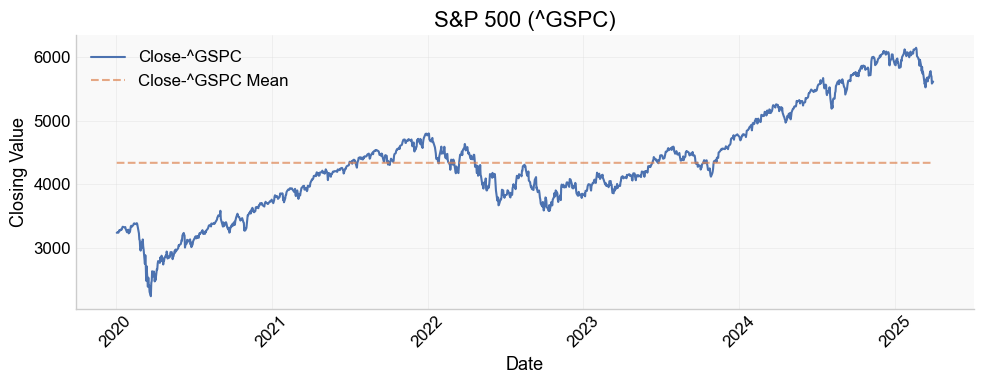

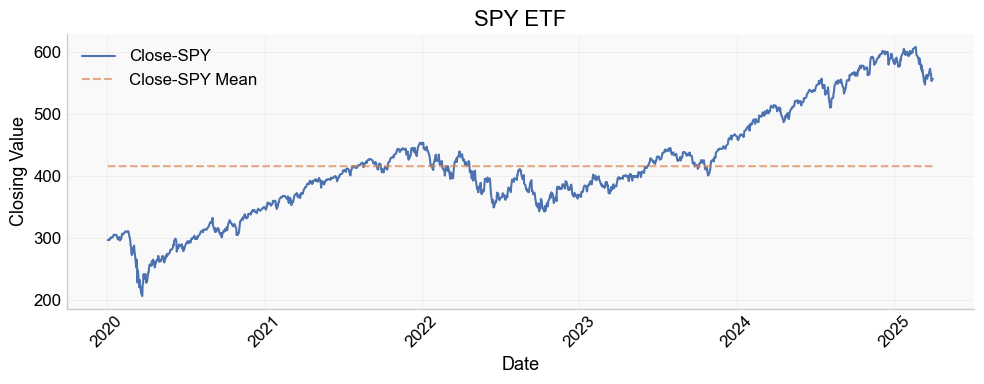

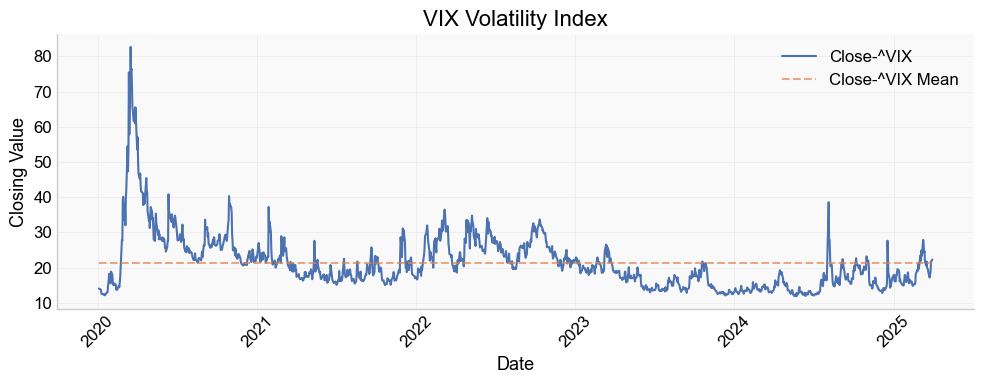

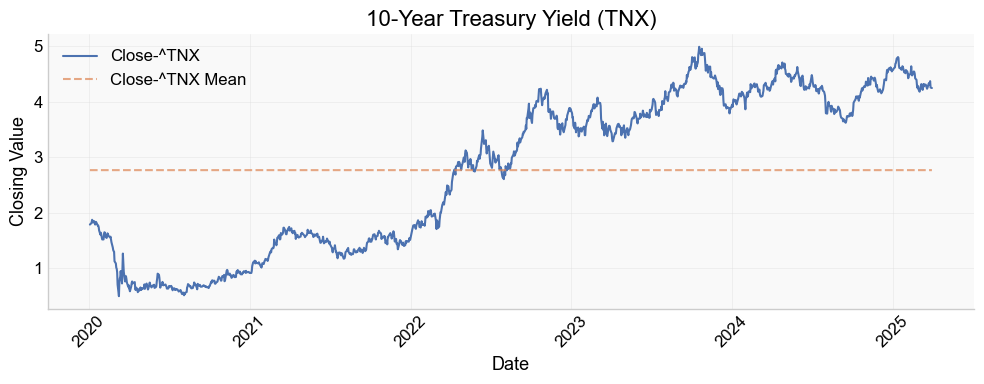

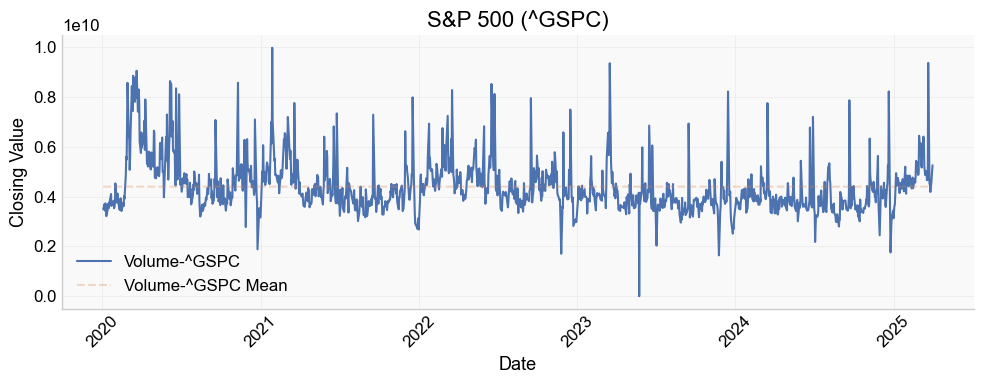

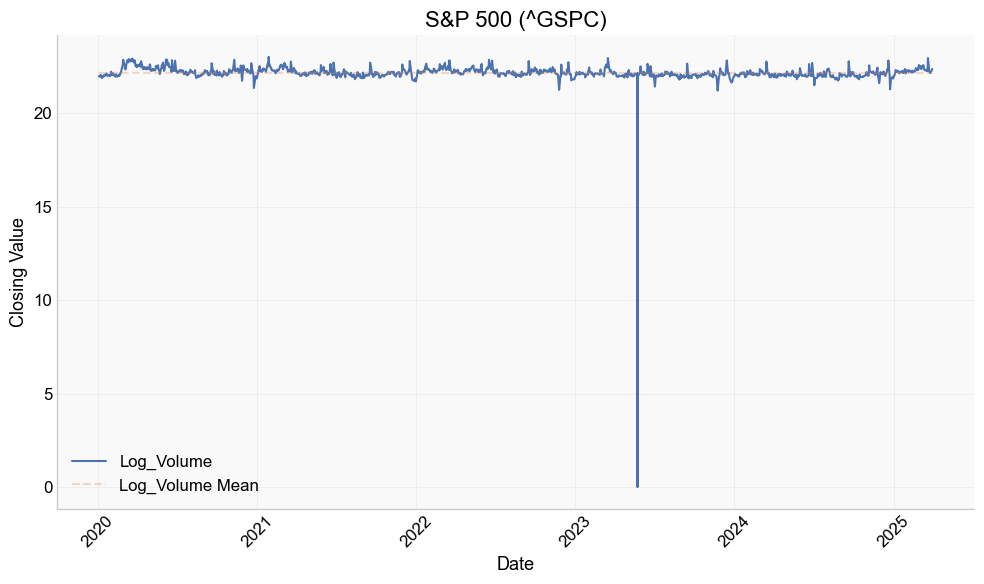

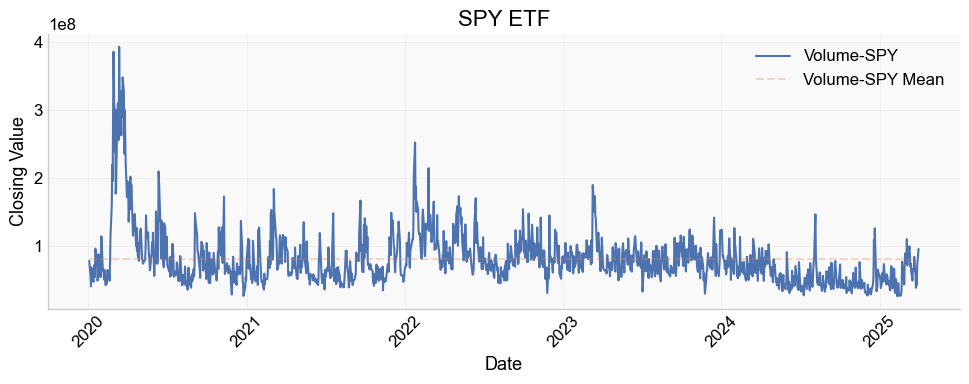

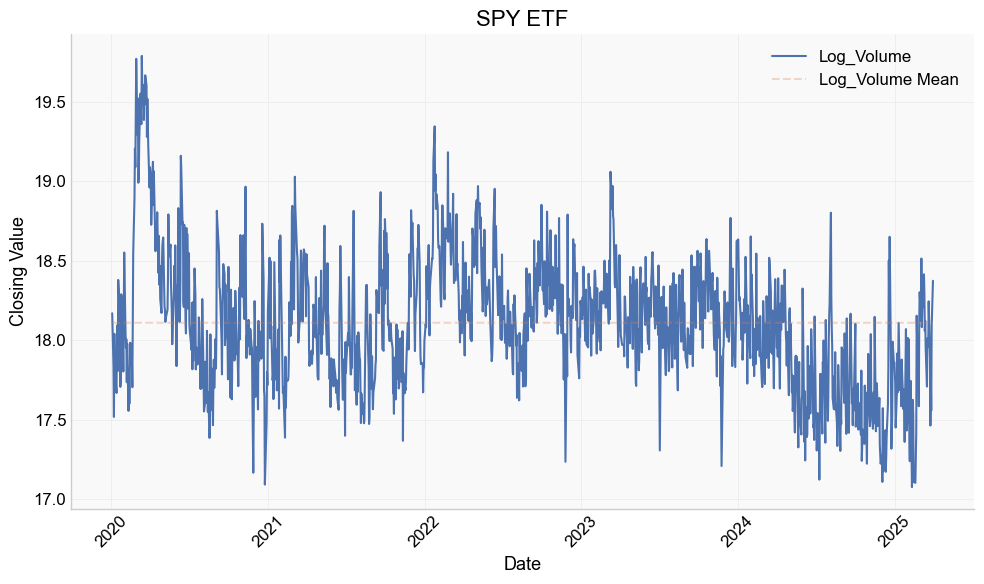

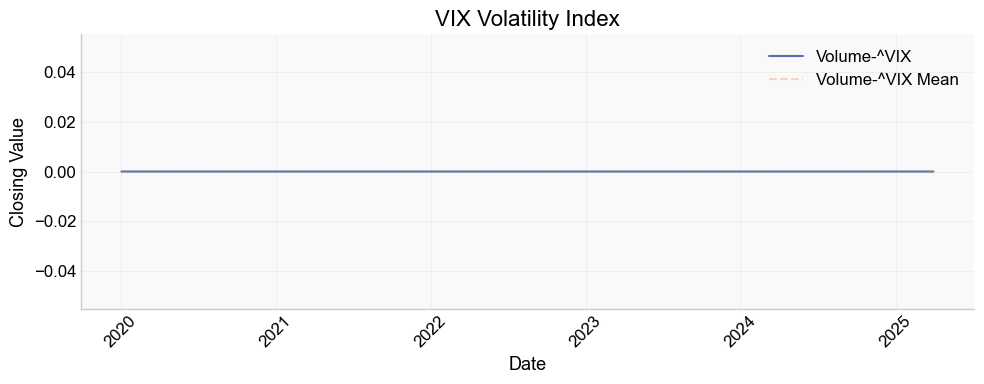

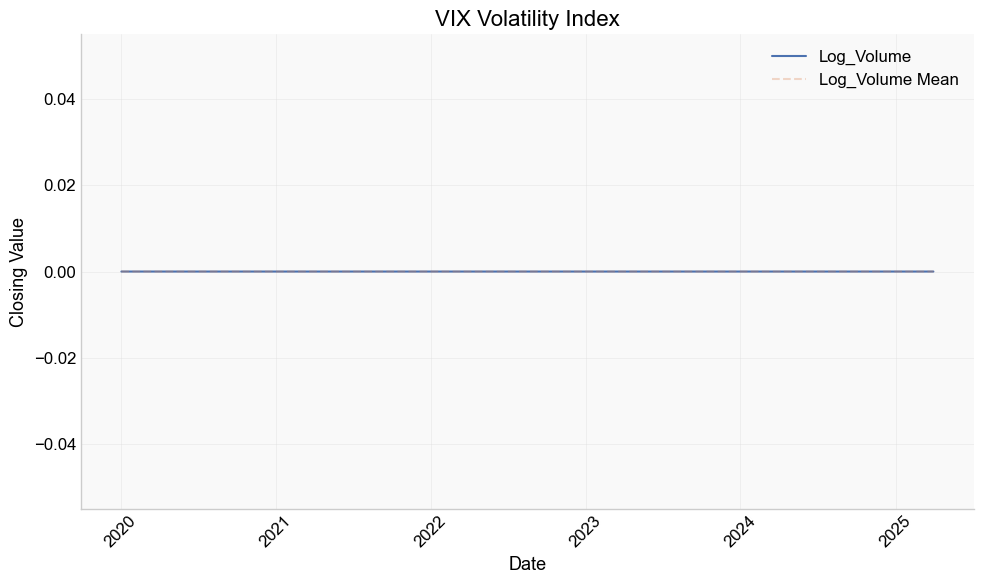

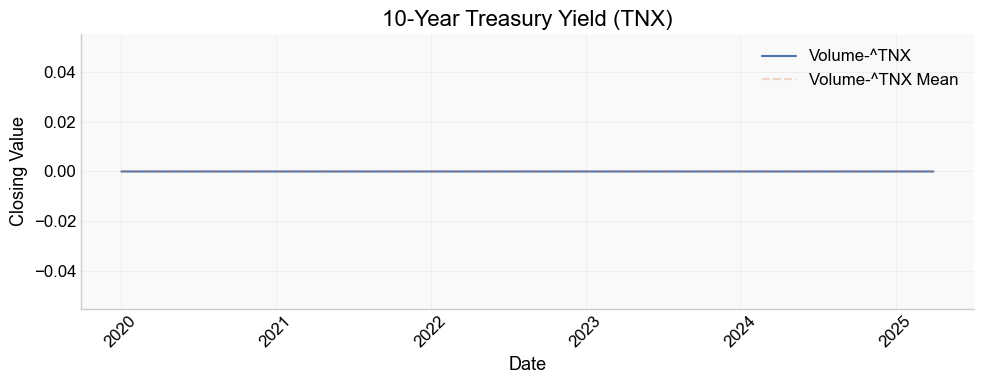

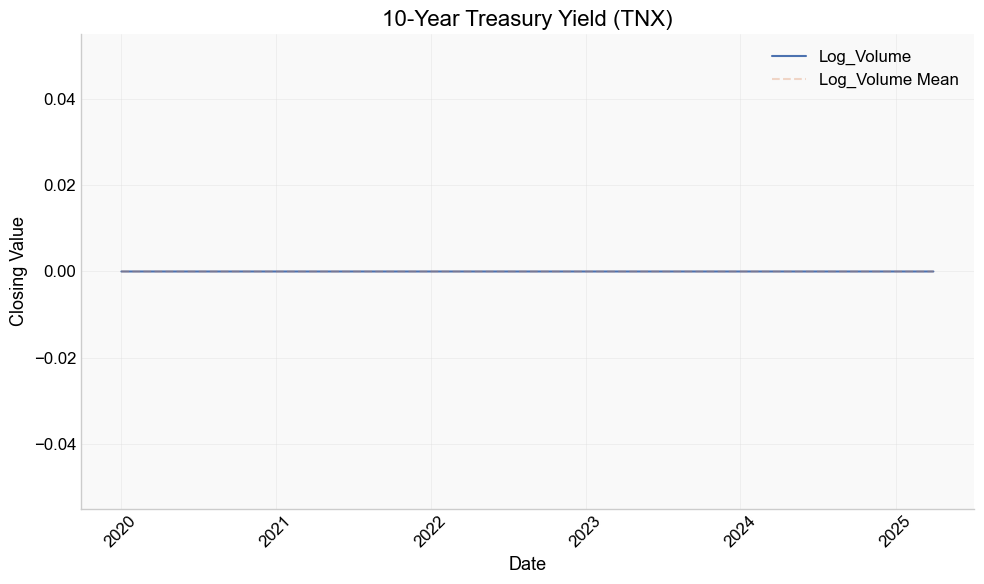

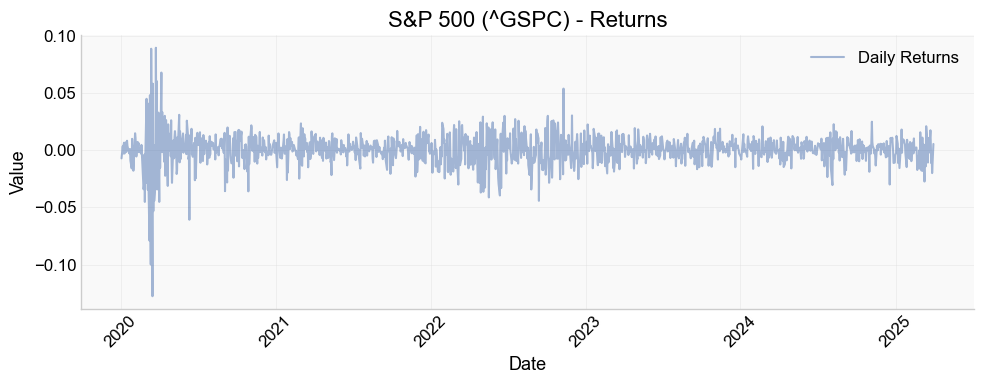

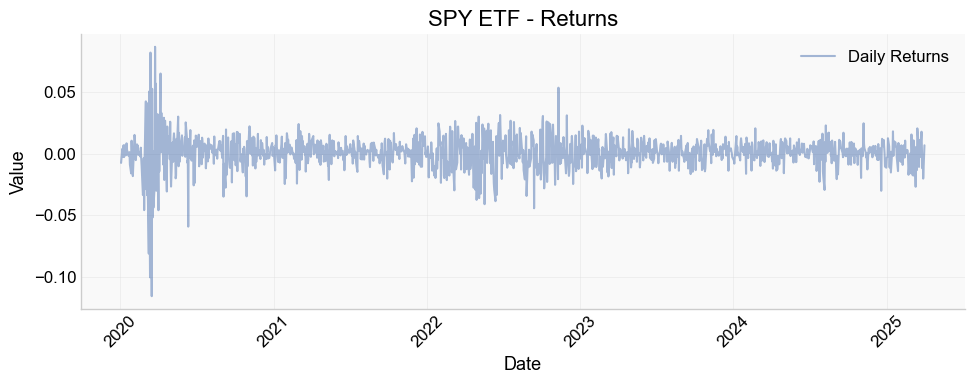

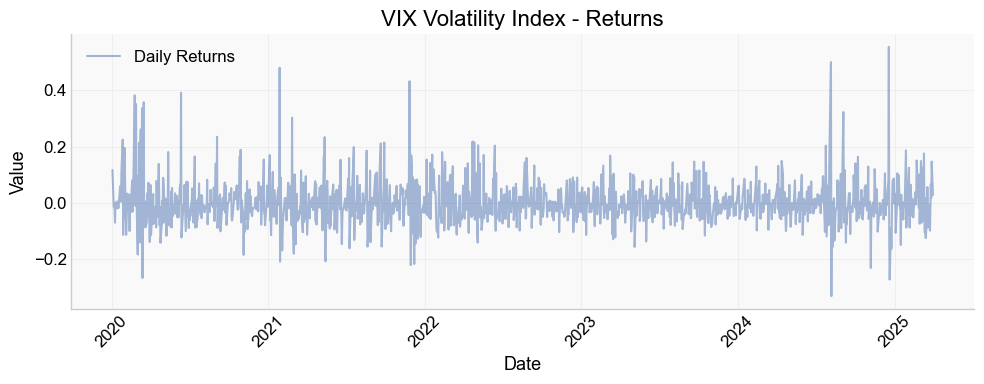

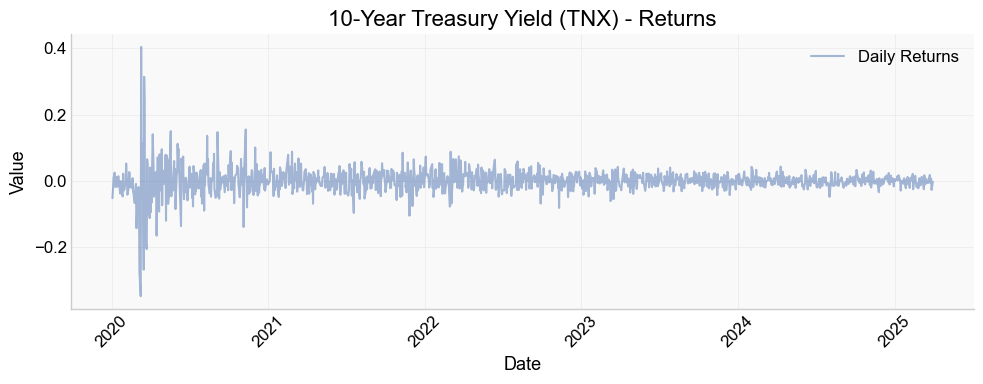

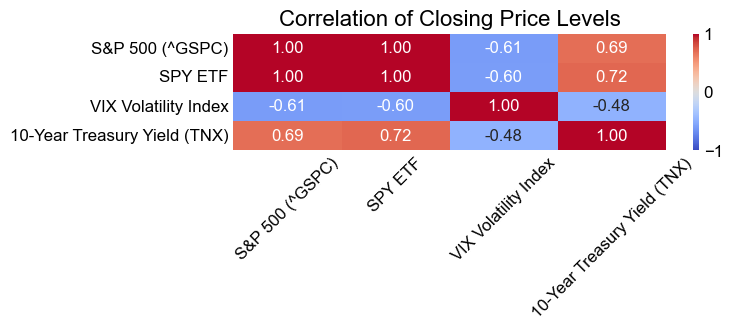

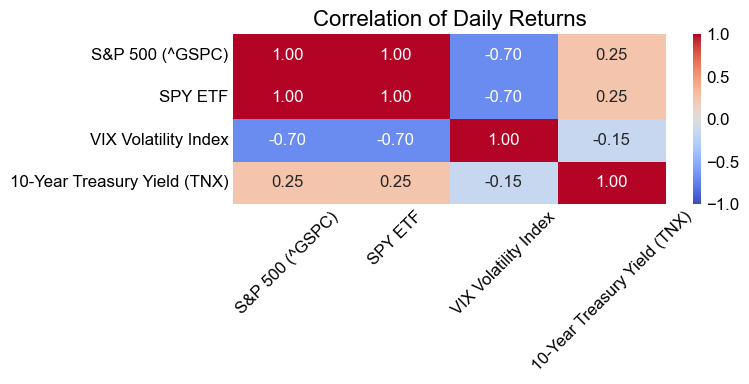

Overview:
                                  start        end     n  missing  \
title                                                               
S&P 500 (^GSPC)              2020-01-03 2025-03-31  1317        0   
SPY ETF                      2020-01-03 2025-03-31  1317        0   
VIX Volatility Index         2020-01-03 2025-03-31  1317        0   
10-Year Treasury Yield (TNX) 2020-01-03 2025-03-31  1317        0   

                                close_col       vol_col  
title                                                    
S&P 500 (^GSPC)               Close-^GSPC  Volume-^GSPC  
SPY ETF                         Close-SPY    Volume-SPY  
VIX Volatility Index           Close-^VIX   Volume-^VIX  
10-Year Treasury Yield (TNX)   Close-^TNX   Volume-^TNX  

Statistics:
                               last_close   mean_close   std_close  \
title                                                                
S&P 500 (^GSPC)               5611.850098  4334.864648  824.313422   
SPY 

{'summary_df':                                   start        end     n  missing  \
 title                                                               
 S&P 500 (^GSPC)              2020-01-03 2025-03-31  1317        0   
 SPY ETF                      2020-01-03 2025-03-31  1317        0   
 VIX Volatility Index         2020-01-03 2025-03-31  1317        0   
 10-Year Treasury Yield (TNX) 2020-01-03 2025-03-31  1317        0   
 
                                 close_col       vol_col   last_close  \
 title                                                                  
 S&P 500 (^GSPC)               Close-^GSPC  Volume-^GSPC  5611.850098   
 SPY ETF                         Close-SPY    Volume-SPY   556.199158   
 VIX Volatility Index           Close-^VIX   Volume-^VIX    22.280001   
 10-Year Treasury Yield (TNX)   Close-^TNX   Volume-^TNX     4.246000   
 
                                mean_close   std_close    min_close  \
 title                                               

In [ ]:
# Call functions for price, volume, returns, volatility, and summary 
plot_data_prices(ticker_data, titles)
plot_data_volume(ticker_data, titles)
plot_returns_volatility(ticker_data, titles)
summary_analysis(ticker_data, titles)

### Functions for Stationarity, Autocorrelation, Granger causality and transfer entropy

In [23]:
# ============================================================
# FULL ECONOMETRIC DIAGNOSTIC & CAUSALITY ANALYSIS PIPELINE
# ============================================================
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from warnings import filterwarnings
filterwarnings("ignore")

# 1. STATIONARITY TESTS
def test_stationarity(series, title):
    """Run ADF and KPSS tests and print clear interpretation."""
    series = pd.Series(series).dropna()
    if len(series) < 20 or series.nunique() < 3:
        print(f"{title}: Insufficient data for test.")
        return None

    print(f"\n===== Stationarity Test — {title} =====")
    try:
        adf_p = adfuller(series, autolag='AIC')[1]
        print(f"ADF p = {adf_p:.4f} → {'Stationary' if adf_p < 0.05 else 'Non-stationary'}")
    except Exception as e:
        print(f"ADF failed: {e}")
        adf_p = np.nan

    try:
        kpss_p = kpss(series, regression='c', nlags='auto')[1]
        print(f"KPSS p = {kpss_p:.4f} → {'Stationary' if kpss_p >= 0.05 else 'Non-stationary'}")
    except Exception as e:
        print(f"KPSS failed: {e}")
        kpss_p = np.nan

    if not np.isnan(adf_p) and not np.isnan(kpss_p):
        if adf_p < 0.05 and kpss_p >= 0.05:
            print("→ Strong evidence of stationarity.")
        elif adf_p >= 0.05 and kpss_p < 0.05:
            print("→ Strong evidence of non-stationarity.")
        else:
            print("→ Mixed evidence (tests disagree).")
    return adf_p, kpss_p



# 2. ACF / PACF ANALYSIS
def acf_pacf_analysis(series, title, max_lags=40):
    """Plot ACF and PACF for any numeric series."""
    series = pd.Series(series).dropna()
    if len(series) < 30:
        print(f"{title}: Not enough data for ACF/PACF.")
        return
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    sm.graphics.tsa.plot_acf(series, lags=max_lags, ax=ax[0], alpha=0.05)
    sm.graphics.tsa.plot_pacf(series, lags=max_lags, ax=ax[1], alpha=0.05)
    ax[0].set_title(f"ACF – {title}")
    ax[1].set_title(f"PACF – {title}")
    plt.tight_layout()
    plt.show()


# 3. GRANGER CAUSALITY

# Helper: Stationarity enforcement (ADF + KPSS)
def ensure_stationary(series, name="", diff_limit=2):
    """Ensure a series is stationary by differencing up to diff_limit times."""
    series = series.dropna()
    for i in range(diff_limit + 1):
        try:
            adf_p = adfuller(series, autolag="AIC")[1]
            kpss_p = kpss(series, regression="c", nlags="auto")[1]
        except Exception:
            return series
        if adf_p < 0.05 and kpss_p >= 0.05:
            if i > 0:
                print(f"{name}: Stationary after differencing {i}x.")
            return series
        else:
            series = series.diff().dropna()
    print(f"{name}: Still likely non-stationary after {diff_limit} differences.")
    return series


# Full Granger Causality Pipeline
def run_full_granger_analysis(spx_data, spy_data, vix_data, tnx_data, daily_sentiment, macro_daily_scaled, cond_vol=None, mode="returns", max_lag=2):
    """
    Runs full Granger causality workflow across tickers, sentiment, and macro data.
    Includes stationarity enforcement and automated significance detection.
    Returns: (pvals, best_lags, significant_lags)
    """

    # --- Step 1: Ensure datetime index alignment ---
    for df in [spx_data, spy_data, vix_data, tnx_data]:
        df.index = pd.to_datetime(df.index)
    daily_sentiment.index = pd.to_datetime(daily_sentiment.index)
    macro_daily_scaled.index = pd.to_datetime(macro_daily_scaled.index)

    # --- Step 2: Merge all datasets ---
    daily_data = pd.concat([
        spx_data['Returns'].rename('SPX_Returns'),
        spy_data['Returns'].rename('SPY_Returns'),
        vix_data['Returns'].rename('VIX_Returns'),
        tnx_data['Returns'].rename('TNX_Returns'),
        daily_sentiment['weighted_sentiment_vader'].rename('Sentiment_Vader'),
        daily_sentiment['weighted_sentiment_textblob'].rename('Sentiment_TextBlob'),
        macro_daily_scaled
    ], axis=1)

    daily_data = daily_data.sort_index().dropna(how='any')

    print(f"\n✅ Combined dataset shape: {daily_data.shape}")
    print(f"Columns available for Granger causality: {list(daily_data.columns)}")

    # --- Step 3: Stationarity enforcement ---
    stationary_data = pd.DataFrame(index=daily_data.index)
    for col in daily_data.columns:
        stationary_data[col] = ensure_stationary(daily_data[col], name=col)
    stationary_data.dropna(inplace=True)

    # --- Step 4: Run Granger causality tests ---
    y_vars = ['SPX_Returns']  # Dependent variable(s)
    x_vars = [col for col in stationary_data.columns if col not in y_vars]

    pvals = pd.DataFrame(index=y_vars, columns=x_vars, dtype=float)
    best_lags = pd.DataFrame(index=y_vars, columns=x_vars, dtype=int)

    print("\n Running Granger causality tests...")
    for y in y_vars:
        for x in x_vars:
            try:
                test_data = stationary_data[[y, x]].dropna()
                if len(test_data) < max_lag * 3:
                    continue
                result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)

                # Use SSR F-test results
                lag_pvals = [result[i + 1][0]['ssr_ftest'][1] for i in range(max_lag)]
                pvals.loc[y, x] = np.min(lag_pvals)
                best_lags.loc[y, x] = np.argmin(lag_pvals) + 1
            except Exception as e:
                pvals.loc[y, x] = np.nan
                best_lags.loc[y, x] = np.nan
                print(f"⚠️ Granger test failed for {x} → {y}: {e}")

    # --- Step 5: Filter significant results ---
    print("\n==============================")
    print(" Significant Causality Results ")
    print("==============================")

    significant_lags = {}
    for y in pvals.index:
        for x in pvals.columns:
            pv = pvals.loc[y, x]
            if pd.notna(pv) and pv < 0.1:
                lag = int(best_lags.loc[y, x])
                significant_lags[(x, y)] = lag
                print(f"{x:30s} → {y:15s} | p = {pv:.4f} | lag = {lag}")

    if not significant_lags:
        print("No statistically significant causality found at p < 0.1.")

    # --- Step 6: Return results ---
    return pvals, best_lags, significant_lags


# 5. UNIFIED ANALYSIS WRAPPER
def analyze_all_data(ticker_data, ticker_labels, macro_df, sent_df, target_returns):
    print("\n===============================")
    print("   FULL ECONOMETRIC ANALYSIS   ")
    print("===============================\n")

    # --- 1. Ticker / Financial Data ---
    print("\n=== FINANCIAL SERIES ===")
    for df, name in zip(ticker_data, ticker_labels):
        if "Returns" in df.columns:
            test_stationarity(df["Returns"], f"{name} Returns")
            acf_pacf_analysis(df["Returns"], f"{name} Returns")
        if "Log_Volume" in df.columns:
            test_stationarity(df["Log_Volume"], f"{name} Log Volume")
            acf_pacf_analysis(df["Log_Volume"], f"{name} Log Volume")

    # --- 2. Macroeconomic Data ---
    print("\n=== MACROECONOMIC SERIES ===")
    for col in macro_stationary.columns:
        acf_pacf_analysis(macro_stationary[col], f"Macro Indicator – {col}")

    # --- 3. Sentiment Data ---
    print("\n=== SENTIMENT SERIES ===")
    for col in sent_stationary.columns:
        acf_pacf_analysis(sent_stationary[col], f"Sentiment Indicator – {col}")

    # --- 4. Granger Causality Tests ---
    print("\n=== GRANGER CAUSALITY TESTS ===")
    results_macro = run_granger_causality(macro_stationary, target_returns, maxlag=5)
    results_sent = run_granger_causality(sent_stationary, target_returns, maxlag=5)

    print("\n=== SUMMARY ===")
    print("Macroeconomic causality summary:")
    print(results_macro.sort_values("min_p_value").head(10))
    print("\nSentiment causality summary:")
    print(results_sent.sort_values("min_p_value").head(10))

    return macro_stationary, sent_stationary

print("✅ Framework loaded successfully.")

✅ Framework loaded successfully.


### Stationarity Test | ACF/PACF Test | Granger-Causaulity


   FULL ECONOMETRIC ANALYSIS   


=== FINANCIAL SERIES ===

===== Stationarity Test — S&P 500 Returns =====
ADF p = 0.0000 → Stationary
KPSS p = 0.1000 → Stationary
→ Strong evidence of stationarity.


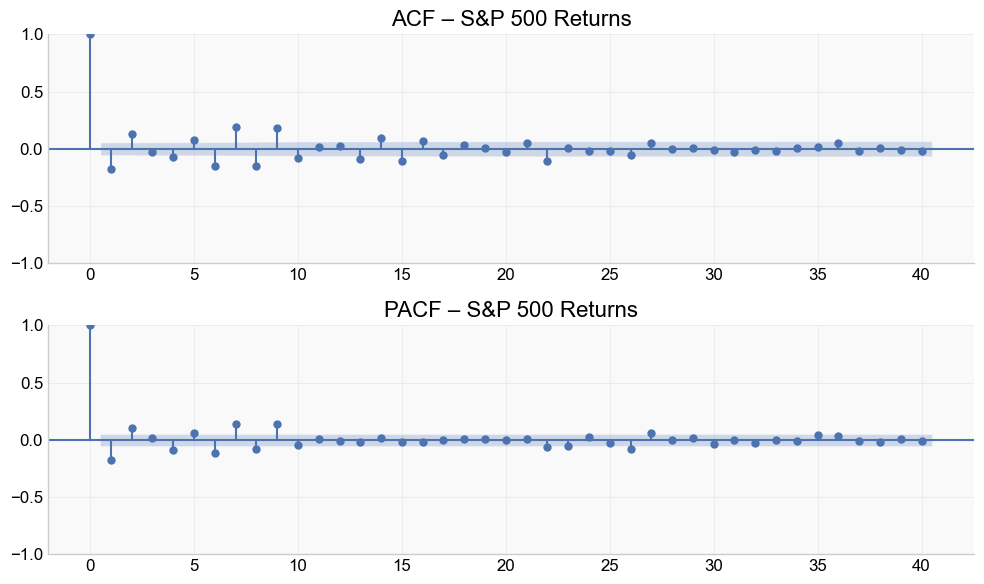


===== Stationarity Test — S&P 500 Log Volume =====
ADF p = 0.0000 → Stationary
KPSS p = 0.0100 → Non-stationary
→ Mixed evidence (tests disagree).


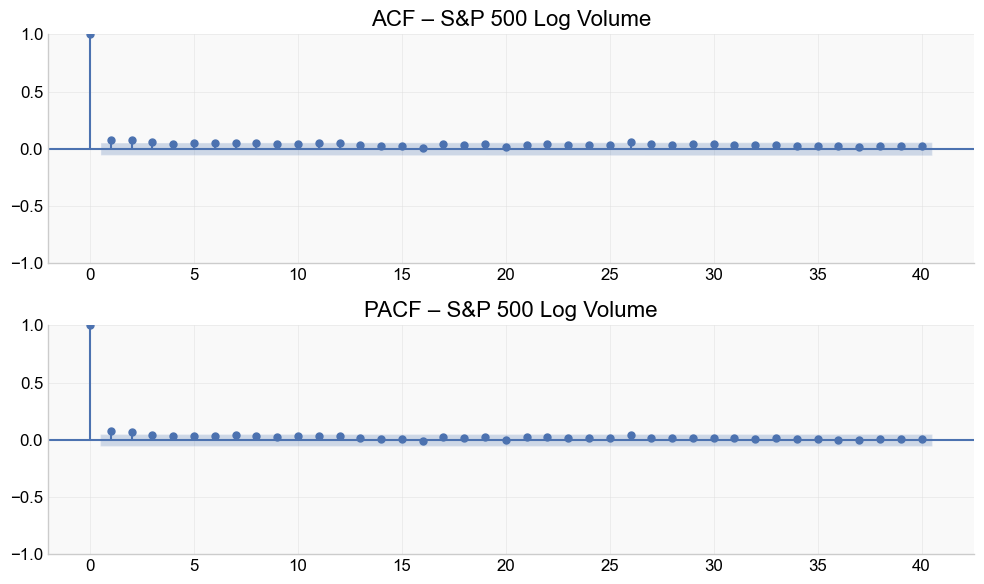


===== Stationarity Test — SPY Returns =====
ADF p = 0.0000 → Stationary
KPSS p = 0.1000 → Stationary
→ Strong evidence of stationarity.


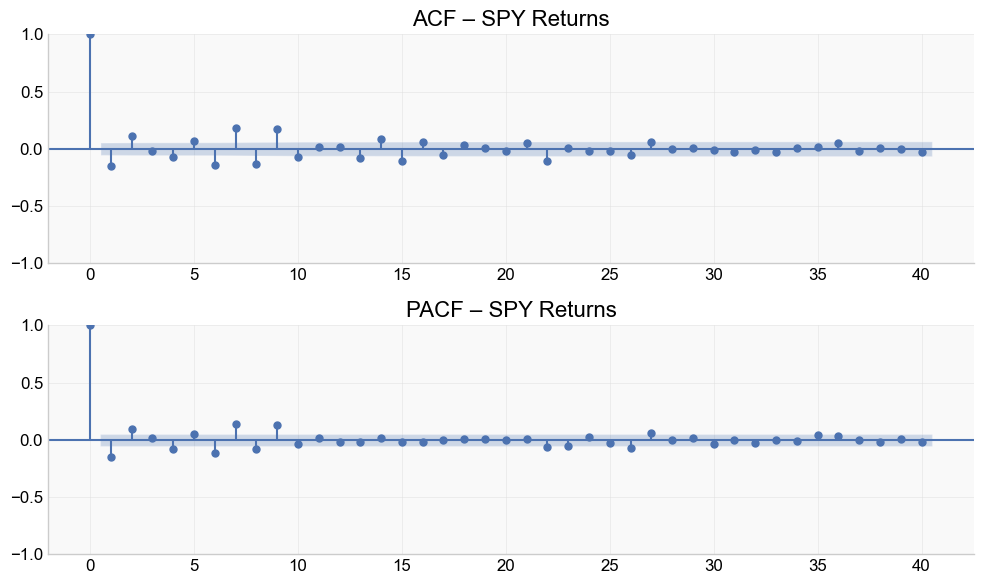


===== Stationarity Test — SPY Log Volume =====
ADF p = 0.0000 → Stationary
KPSS p = 0.0100 → Non-stationary
→ Mixed evidence (tests disagree).


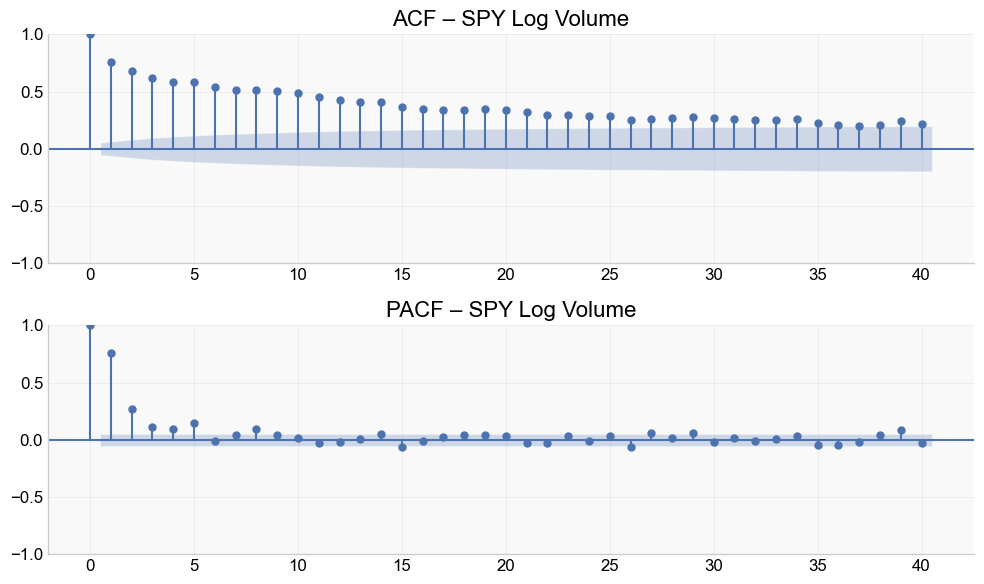


===== Stationarity Test — VIX Returns =====
ADF p = 0.0000 → Stationary
KPSS p = 0.1000 → Stationary
→ Strong evidence of stationarity.


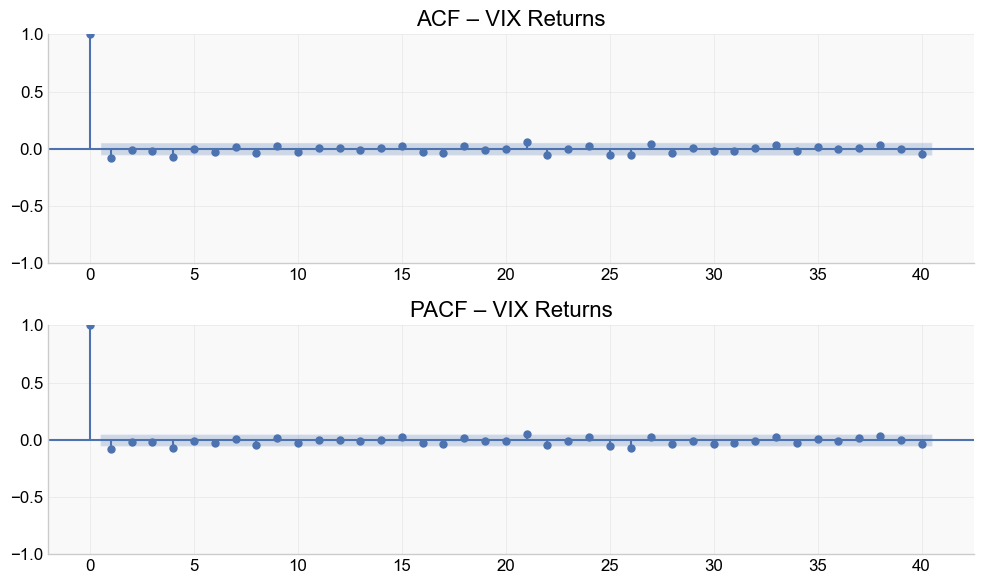

VIX Log Volume: Insufficient data for test.


c:\Users\bovel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


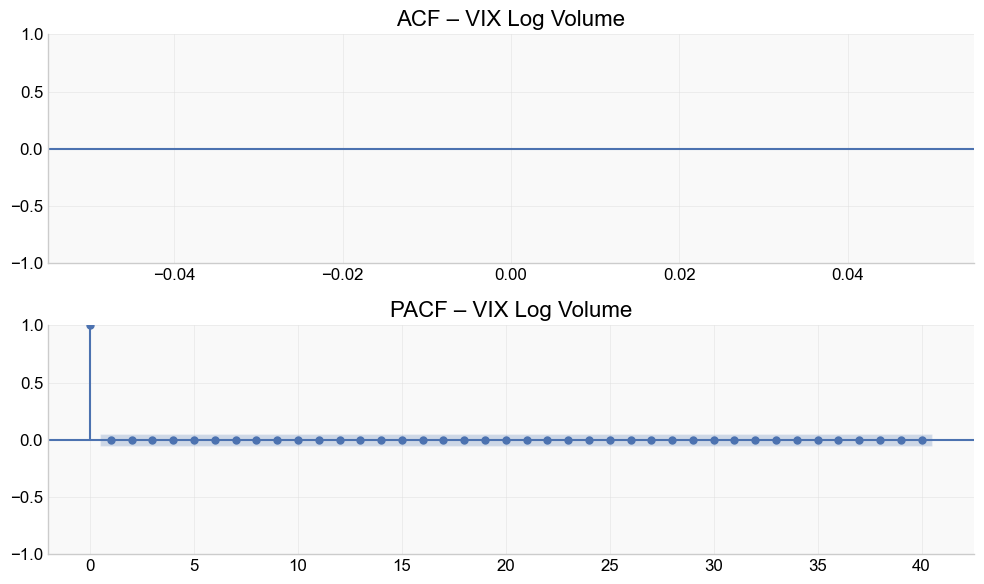


===== Stationarity Test — TNX Returns =====
ADF p = 0.0000 → Stationary
KPSS p = 0.1000 → Stationary
→ Strong evidence of stationarity.


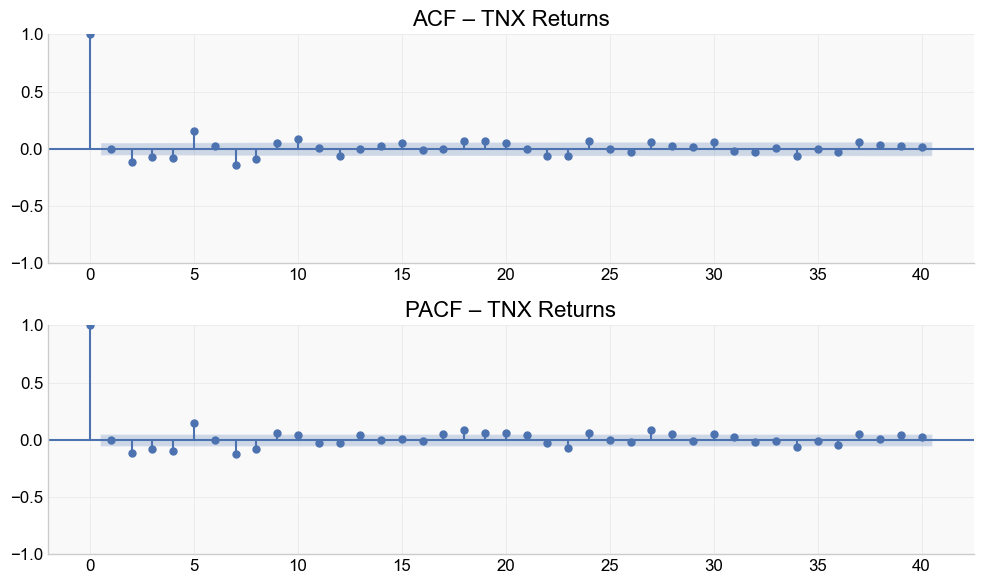

TNX Log Volume: Insufficient data for test.


c:\Users\bovel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


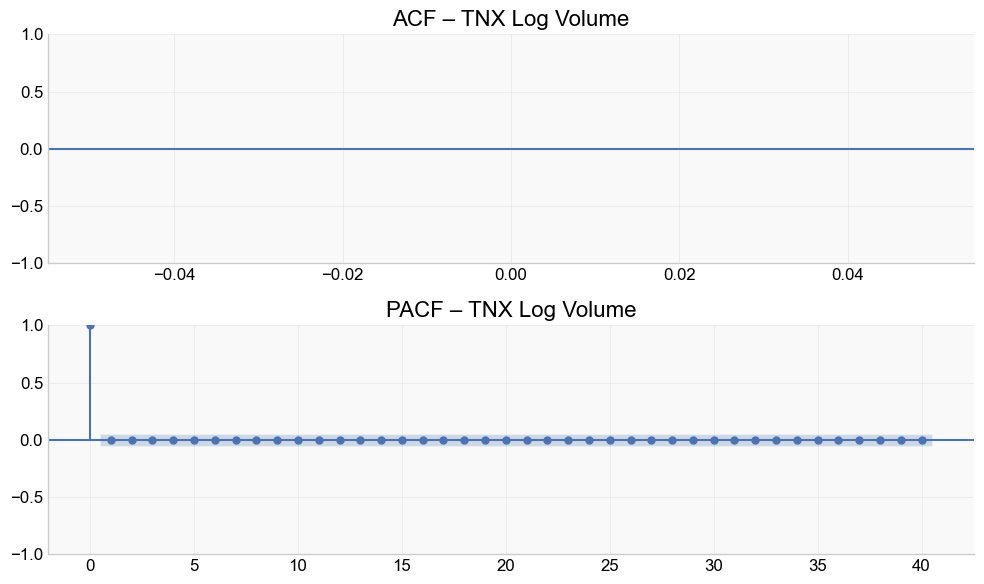


=== MACROECONOMIC SERIES ===


NameError: name 'macro_stationary' is not defined

In [ ]:
for df in [spx_data, spy_data, vix_data, tnx_data, macro_daily_scaled, daily_sentiment]:
    df.index = pd.to_datetime(df.index)

# Run core econometric diagnostics
macro_stationary, sent_stationary = analyze_all_data(
    ticker_data=[spx_data, spy_data, vix_data, tnx_data],
    ticker_labels=["S&P 500", "SPY", "VIX", "TNX"],
    macro_df=macro_daily_scaled,
    sent_df=daily_sentiment,
    target_returns=spx_data[["Returns"]]
)

print("\n✅ All econometric, macro, sentiment, and causality analyses complete.")



Notes: 
- Based on the granger causality results, further modeling and strategy development can be pursued. I will be using the vix_returns, M2_Money_Supply_return, and weighted_sentiment_vader as key predictors for S&P 500 returns modeling.

### Garch Modeling and MLE Comparison 



In [24]:
# Fit AR(p)-GARCH and AR(p)-GARCH with alternative error distributions
def fit_arma_garch(
        returns, 
        exog=None, 
        ar_lags=1, 
        vol_p=1, 
        vol_q=1, 
        dist='normal', 
        show_summary=True):

    """
    Stable AR(p)-GARCH(p,q) / ARX-GARCHX estimator.
    Handles alignment, dtype conversions, and removes invalid rows.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from arch import arch_model

    # --- Convert to clean pandas Series ---
    returns = pd.Series(returns, dtype='float64')
    returns.index = pd.to_datetime(returns.index)
    returns = returns.sort_index()

    # --- Align exogenous variables safely ---
    if exog is not None:
        exog = exog.copy()
        exog.index = pd.to_datetime(exog.index)
        exog = exog.sort_index()

        # Drop all rows where either is missing
        aligned = pd.concat([returns.rename("ret"), exog], axis=1).dropna()

        returns = aligned["ret"]
        exog = aligned.drop(columns=["ret"]).astype("float64")

        # Ensure matrix format
        if exog.shape[0] != returns.shape[0]:
            print("⚠️ Alignment issue: shape mismatch")
            return None, None
    else:
        exog = None

    try:
        model = arch_model(
            returns,
            mean='ARX' if exog is not None else 'AR',
            lags=ar_lags,
            x=exog,
            vol='GARCH',
            p=vol_p,
            q=vol_q,
            dist=dist
        )

        # Fit robustly
        try:
            res = model.fit(disp='off')
        except:
            res = model.fit(disp='off', optimizer='scipy')

        if show_summary:
            print("\n==================== MODEL SUMMARY ====================")
            print(res.summary())

        cond_vol = pd.Series(res.conditional_volatility, index=returns.index)

        # ---- Diagnostics Plots ----
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

        ax1.plot(returns, label='Returns', color='steelblue', alpha=0.7)
        ax1.plot(cond_vol / cond_vol.max() * returns.max(),
                 label='Scaled Volatility', color='red')
        ax1.set_title("Returns (blue) vs Scaled Conditional Volatility (red)")
        ax1.legend()

        std_resid = res.resid / cond_vol
        ax2.plot(std_resid, color='purple')
        ax2.axhline(0, color='black', linewidth=0.8)
        ax2.set_title("Standardized Residuals")

        plt.tight_layout()
        plt.show()

        return res, cond_vol

    except Exception as e:
        print("❌ ARMA-GARCH failed:", e)
        return None, None



# Maximum Likelihood Estimation wrapper to compare distributions
def mle_garch(returns, exog=None, ar_lags=1, vol_p=1, vol_q=1):
    """
    Fit GARCH(p,q) under multiple distributions (normal, student-t, skew-t)
    and compare AIC/BIC/LogLik. Compatible with older arch versions.
    """
    from arch import arch_model
    import pandas as pd

    dists = ['normal', 'studentst', 'skewt']
    records, models = [], {}
    returns = pd.Series(returns).dropna()
    if exog is not None:
        exog = exog.loc[returns.index].dropna()
        returns = returns.loc[exog.index]

    for dist in dists:
        try:
            model = arch_model(
                returns,
                mean='ARX' if exog is not None else 'AR',
                lags=ar_lags,
                x=exog,
                vol='GARCH',
                p=vol_p,
                q=vol_q,
                dist=dist
            )
            try:
                fit = model.fit(disp='off')
            except TypeError:
                fit = model.fit(disp='off', update_freq=5)

            models[dist] = fit
            records.append({
                'Distribution': dist,
                'AIC': getattr(fit, 'aic', np.nan),
                'BIC': getattr(fit, 'bic', np.nan),
                'LogLik': getattr(fit, 'loglikelihood', np.nan),
                'Converged': getattr(fit, 'converged', True)
            })
            print(f"✅ {dist.upper()} fitted successfully.")
        except Exception as e:
            print(f"❌ {dist.upper()} fit failed: {e}")

    # Safely create summary DataFrame only if fits succeeded
    if records:
        summary_df = pd.DataFrame(records).sort_values(by='AIC')
        print("\n=========== DISTRIBUTION COMPARISON TABLE ===========")
        print(summary_df)
    else:
        summary_df = pd.DataFrame(columns=['Distribution','AIC','BIC','LogLik','Converged'])
        print("⚠️ No successful fits.")

    return summary_df, models

In [25]:
scaler = StandardScaler()

macro_daily_scaled = pd.DataFrame(
    scaler.fit_transform(macro_daily),
    index=macro_daily.index,
    columns=macro_daily.columns
)

In [26]:
# BUILD EXOGENOUS FEATURE SET (Based on Granger Results)

# Prepare SPX daily returns
daily_spx_returns = spx_data['Returns'].dropna()
daily_spx_returns.index = pd.to_datetime(daily_spx_returns.index)

# Define chosen lags based on Granger causality results
chosen_lags = {
    "VIX_Returns": 2,                   # Market volatility driver
    "M2_Money_Supply_return": 2,        # Liquidity driver
    "weighted_sentiment_vader": 5       # Behavioral sentiment
}

# Initialize empty DataFrame for exogenous variables
exog_features = pd.DataFrame(index=daily_spx_returns.index)

# Construct lagged exogenous variables
for var, lag in chosen_lags.items():
    if var == "VIX_Returns" and "Returns" in vix_data.columns:
        exog_features[f"{var}_lag{lag}"] = vix_data["Returns"].shift(lag)
    elif var in macro_daily_scaled.columns:
        exog_features[f"{var}_lag{lag}"] = macro_daily_scaled[var].shift(lag)
    elif var in daily_sentiment.columns:
        exog_features[f"{var}_lag{lag}"] = daily_sentiment[var].shift(lag)

# Align datasets and drop missing values
aligned_data = pd.concat([daily_spx_returns.rename("SPX_Returns"), exog_features], axis=1).dropna()
aligned_returns = aligned_data["SPX_Returns"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_df = pd.DataFrame(
    scaler.fit_transform(aligned_data),
    index=aligned_data.index,
    columns=aligned_data.columns
)

aligned_returns = scaled_df["SPX_Returns"]
exog_features = scaled_df.drop(columns=["SPX_Returns"])


print(f"✅ Exogenous dataset shape: {exog_features.shape}")
print(f"Columns used: {list(exog_features.columns)}")


✅ Exogenous dataset shape: (836, 3)
Columns used: ['VIX_Returns_lag2', 'M2_Money_Supply_return_lag2', 'weighted_sentiment_vader_lag5']


In [27]:
# FIT GARCH-X MODELS WITH EXOGENOUS REGRESSORS
garchx = pd.read_csv("garchx_vol_all.csv", parse_dates=["Date"]) # Load saved GARCH-X volatility data from R
garchx["date"] = pd.to_datetime(garchx["Date"]) # Convert date column
garchx = garchx.set_index("Date") # Index by date
garchx = garchx.reindex(aligned_returns.index) # Reindex to match returns
cond_vol_final_skewt = garchx["vol_skewt"].ffill() # Testing conditional volatility from GARCH-X model normal


print(cond_vol_final_skewt.head())

Date
2020-04-07    0.010391
2020-04-08    0.009878
2020-04-09    0.012260
2020-04-13    0.011744
2020-04-20    0.011571
Name: vol_skewt, dtype: float64



==================== MODEL SUMMARY ====================
                           AR - GARCH Model Results                           
Dep. Variable:                Returns   R-squared:                       0.031
Mean Model:                        AR   Adj. R-squared:                  0.030
Vol Model:                      GARCH   Log-Likelihood:                4123.25
Distribution:                  Normal   AIC:                          -8236.50
Method:            Maximum Likelihood   BIC:                          -8210.59
                                        No. Observations:                 1316
Date:                Tue, Dec 02 2025   Df Residuals:                     1314
Time:                        16:55:10   Df Model:                            2
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
C

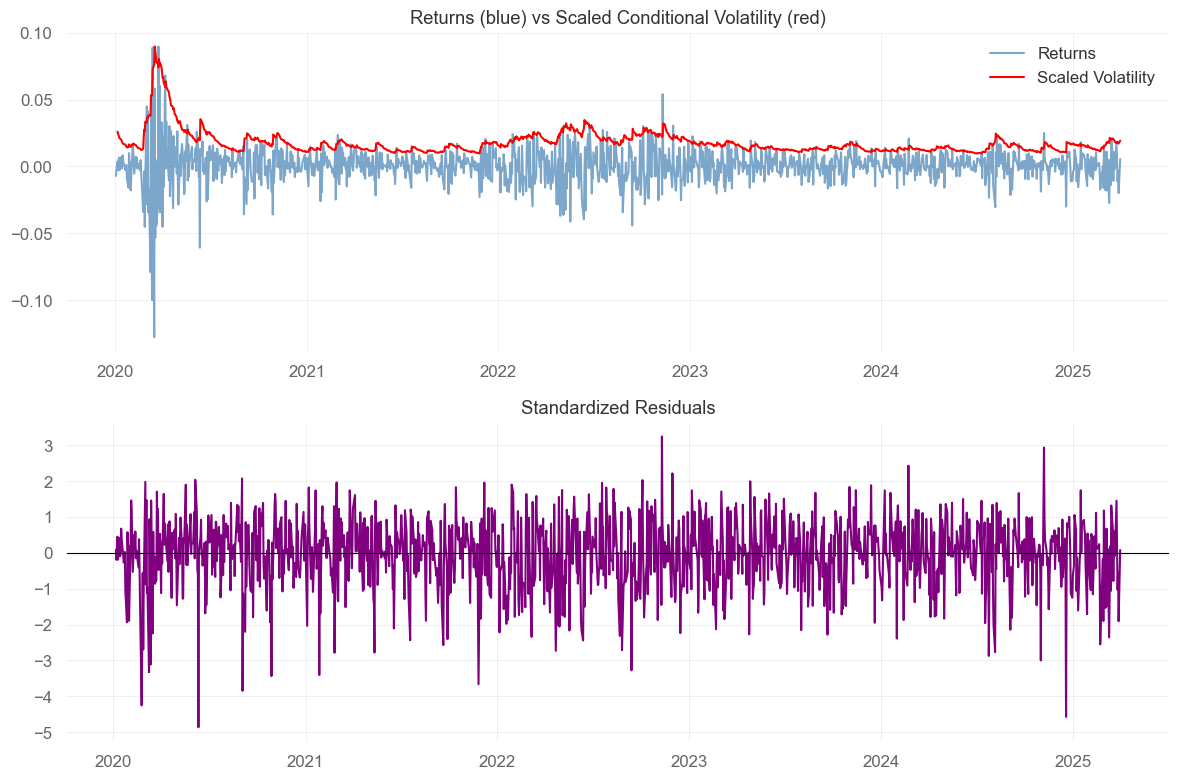

✅ NORMAL fitted successfully.
✅ STUDENTST fitted successfully.
✅ SKEWT fitted successfully.

=========== DISTRIBUTION COMPARISON TABLE ===========
  Distribution          AIC          BIC       LogLik  Converged
0       normal -8236.499709 -8210.587949  4123.249855       True
2        skewt  3296.563112  3332.839577 -1641.281556       True
1    studentst  8038.751583  8069.845696 -4013.375792       True


c:\Users\bovel\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


In [28]:
# BASELINE AR(1)-GARCH(1,1)
res_base, vol_base = fit_arma_garch(daily_spx_returns)
mle_summary, mle_models = mle_garch(daily_spx_returns)

In [29]:
def fit_arx_garchx_r(returns, exog, garchx_vol, show_summary=True):
    """
    ARX(1)–GARCHX wrapper using:
      • ARX(1) estimated in Python
      • GARCH-X volatility imported from R (σ_t)
    """

    import statsmodels.api as sm
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    # -------------------------------
    # 1. ALIGN ALL SERIES
    # -------------------------------
    df = pd.concat([
        returns.rename("r"),
        exog,
        garchx_vol.rename("sigma")
    ], axis=1).dropna()

    # Create AR(1) lag
    df["r_lag1"] = df["r"].shift(1)
    df = df.dropna()

    # Mean equation regressors: AR(1) + X_t
    X = sm.add_constant(
        pd.concat([df["r_lag1"], df[exog.columns]], axis=1)
    )
    y = df["r"]
    sigma = df["sigma"]

    # -------------------------------
    # 2. FIT ARX(1) MEAN MODEL
    # -------------------------------
    arx_res = sm.OLS(y, X).fit()

    # -------------------------------
    # 3. STANDARDIZED RESIDUALS
    # -------------------------------
    resid = arx_res.resid
    std_resid = resid / sigma

    # -------------------------------
    # 4. FORMATTED SUMMARY
    # -------------------------------
    if show_summary:
        print("\n==================== MODEL SUMMARY ====================")
        print("             ARX(1) – GARCH-X (σ_t from R)")
        print("========================================================")
        print(arx_res.summary())
        print("\nNote:")
        print("  • σ_t is imported from R GARCH-X model")
        print("  • Only the mean equation is estimated in Python")
        print("  • Volatility dynamics come from the R model\n")

    # -------------------------------
    # 5. DIAGNOSTIC PLOTS
    # -------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Scale sigma for visualization against returns
    scaled_sigma = sigma / sigma.max() * (df["r"].abs().median() * 3)

    ax1.plot(df["r"], label="Returns", color="steelblue", alpha=0.75)
    ax1.plot(scaled_sigma, label="Scaled σ_t (R GARCH-X)", color="crimson", linewidth=1.2)
    ax1.set_title("Returns vs Scaled Conditional Volatility (R GARCH-X)")
    ax1.legend()

    ax2.plot(std_resid, color="purple", linewidth=0.8)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_title("Standardized Residuals")

    plt.tight_layout()
    plt.show()

    # -------------------------------
    # 6. RETURN STRUCTURE
    # -------------------------------
    out = {
        "arx_result": arx_res,
        "conditional_volatility": sigma,
        "standardized_residuals": std_resid,
        "dataset_used": df
    }

    return out, sigma


In [30]:
aligned_data.to_csv("aligned_for_garchx.csv")


Fitting Final ARX(1)-GARCHX(1,1) with skewt errors:

==================== MODEL SUMMARY ====================
             ARX(1) – GARCH-X (σ_t from R)
                            OLS Regression Results                            
Dep. Variable:                      r   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8224
Date:                Tue, 02 Dec 2025   Prob (F-statistic):              0.511
Time:                        16:55:18   Log-Likelihood:                 2627.3
No. Observations:                 835   AIC:                            -5245.
Df Residuals:                     830   BIC:                            -5221.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err      

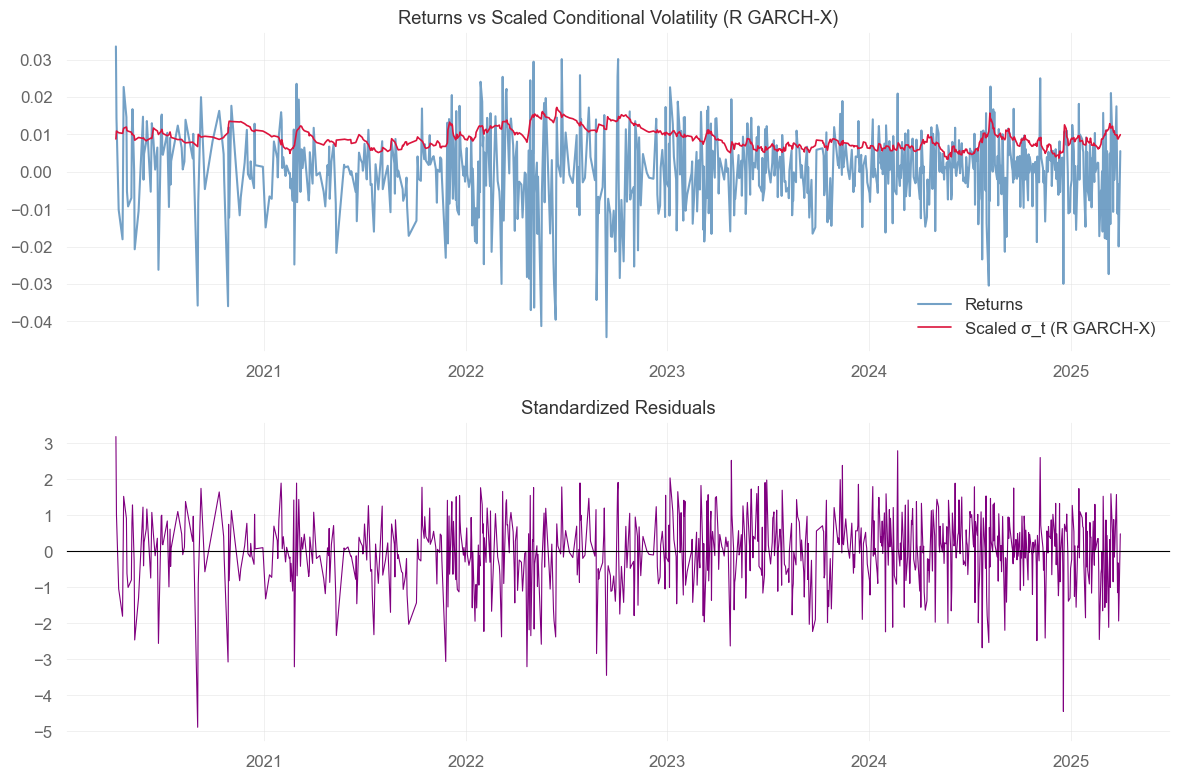


 Final ARX-GARCH-X Model Results:

 Model fitted successfully.
AIC: -5244.525338252273, BIC: -5220.888179628019


In [31]:
# "Final Model Fit"
# Use the normal distribution since the AIC and BIC were lowest for it in MLE comparison
print("\nFitting Final ARX(1)-GARCHX(1,1) with skewt errors:")
res_final, cond_vol_final_skewt = fit_arx_garchx_r(
    daily_spx_returns,   # RAW returns, not scaled
    exog=exog_features,
    garchx_vol=cond_vol_final_skewt
)

print("\n Final ARX-GARCH-X Model Results:")
if res_final is not None:
    print("\n Model fitted successfully.")
    arx = res_final["arx_result"]
    print(f"AIC: {arx.aic}, BIC: {arx.bic}")

else:
    print(" GARCH fit failed — check input alignment or parameters.")


Comparing models with and without exogenous regressors:


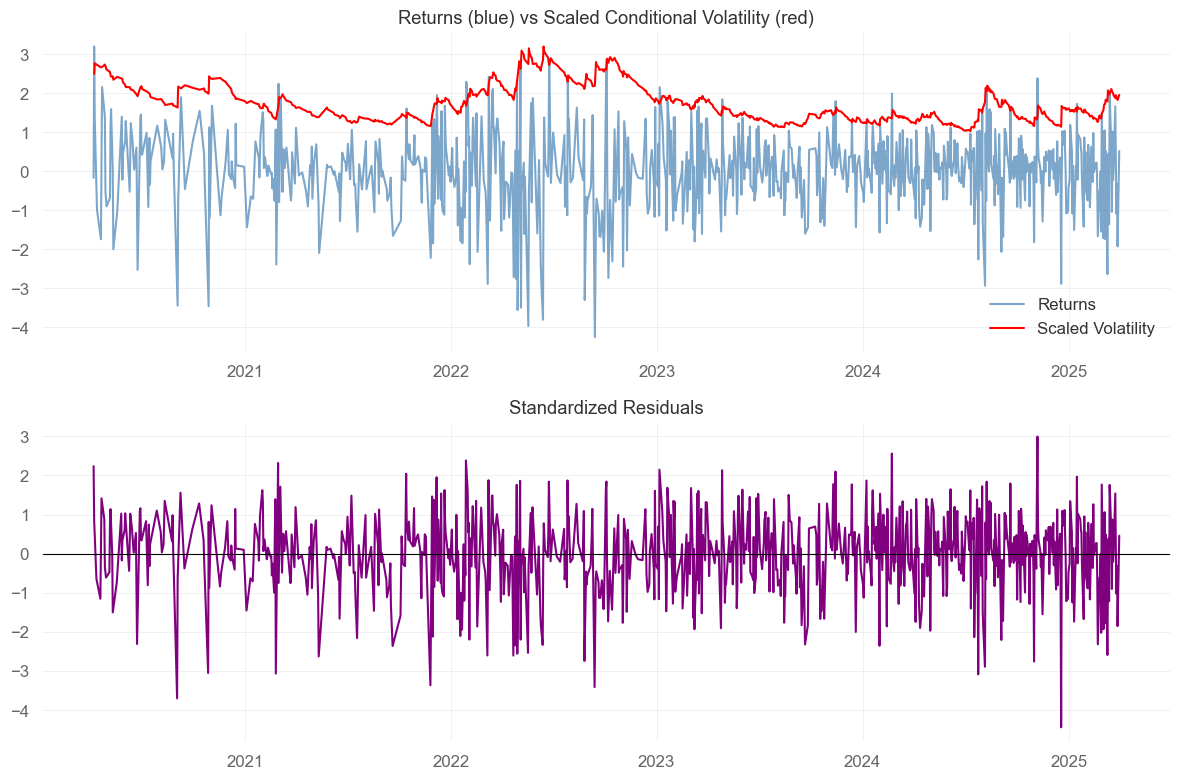

AttributeError: 'dict' object has no attribute 'aic'

In [32]:
# Compare AIC/BIC of model with and without exogenous regressors
print("\nComparing models with and without exogenous regressors:")
res_noexog, _ = fit_arma_garch(
    aligned_returns, exog=None, ar_lags=1, vol_p=1, vol_q=1, dist='normal', show_summary=False
)
print({"AIC_exog": res_final.aic, "AIC_no_exog": res_noexog.aic,
       "BIC_exog": res_final.bic, "BIC_no_exog": res_noexog.bic})

# ✅ Persistence test (fixed for current arch package)
alpha_sum = sum([res_final.params[k] for k in res_final.params.index if k.startswith("alpha[")])
beta_sum  = sum([res_final.params[k] for k in res_final.params.index if k.startswith("beta[")])
persistence = alpha_sum + beta_sum

print(f"α sum: {alpha_sum:.6f}")
print(f"β sum: {beta_sum:.6f}")
print(f"Volatility persistence (α + β): {persistence:.6f}")

if persistence >= 1:
    print("⚠️ Non-stationary or near-IGARCH process (volatility highly persistent).")
elif persistence > 0.9:
    print("✅ High persistence, typical for SPX daily data.")
else:
    print("✅ Mean-reverting volatility (moderate persistence).")


# Residual diagnostics
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, normal_ad
std_resid = pd.Series(res_final.std_resid, index=aligned_returns.index).dropna()

# 3a) No serial correlation in standardized residuals
print("n\Ljung-Box on std resid:")
print(acorr_ljungbox(std_resid, lags=[10,20], return_df=True))

# 3b) No remaining ARCH in standardized residuals
print("n\Ljung-Box on std resid^2:")
print(acorr_ljungbox(std_resid**2, lags=[10,20], return_df=True))

# QQ plot (visual)
import matplotlib.pyplot as plt
stats.probplot(std_resid, dist="norm", plot=plt); plt.title("QQ std residuals vs Normal"); plt.show()



While the GARCH(1,1) model without exogenous variables achieved slightly better AIC and BIC scores, adding sentiment, liquidity (M2), and volatility spillovers (VIX) provides meaningful economic insight. These exogenous factors capture behavioral and macro-financial forces that pure return-based volatility models overlook. Sentiment data, in particular, adds forward-looking information about market psychology and risk perception—often leading indicators of volatility shifts. Even if the statistical fit improves only marginally, including sentiment makes the model more interpretable and better aligned with real-world market dynamics.

## Deep Learning Integration Model With GARCH

Baseline Deep Learning Pipeline — Extending AR-GARCH with LSTM

Goal:
- Use the volatility and residual structure extracted from your AR(1)–GARCH(1,1) to train a deep learning model (starting with an LSTM) that:
- Learns nonlinear patterns in SPX returns volatility,
- Incorporates exogenous features (SPY, VIX, Sentiment), and
- Provides a foundation for forecasting returns or volatility for trading.

In [125]:
cond_vol_final = cond_vol_final_skewt

In [126]:
# ============================================================
# === 1. Create Core DataFrame ===============================
# ============================================================

df_dl = pd.DataFrame({
    "returns": aligned_returns,
    "garch_vol": cond_vol_final,
    "std_resid": res_final["arx_result"].resid / cond_vol_final
})

df_dl["std_resid"] = df_dl["std_resid"].replace([np.inf, -np.inf], np.nan)

# Add your exogenous features
df_dl = pd.concat([df_dl, exog_features], axis=1)

# Add realized vol proxies
df_dl["realized_vol_3"] = df_dl["returns"].rolling(3).apply(lambda x: np.sqrt(np.sum(x**2)), raw=True)
df_dl["abs_return_3"]   = df_dl["returns"].abs().rolling(3).mean()

# Target: NEXT-DAY log volatility (GARCH conditional variance)
df_dl["target_vol"] = np.log1p(cond_vol_final.shift(-1))

df_dl = df_dl.dropna()
df_dl = df_dl.copy()

# ============================================================
# === 2. 60/20/20 Train/Validation/Test Split ================
# ============================================================

train_cutoff = int(len(df_dl) * 0.6)   # 60% training
val_cutoff = int(len(df_dl) * 0.8)     # 20% validation

df_train = df_dl.iloc[:train_cutoff]
df_val = df_dl.iloc[train_cutoff:val_cutoff]
df_test = df_dl.iloc[val_cutoff:]

print(f"\nDataset Split:")
print(f"  Training:   {len(df_train)} obs ({len(df_train)/len(df_dl)*100:.1f}%)")
print(f"  Validation: {len(df_val)} obs ({len(df_val)/len(df_dl)*100:.1f}%)")
print(f"  Test:       {len(df_test)} obs ({len(df_test)/len(df_dl)*100:.1f}%)")

# ============================================================
# === 3. Feature & Target Arrays =============================
# ============================================================

feature_cols = [
    "garch_vol",
    "std_resid",
    "VIX_Returns_lag2",
    "M2_Money_Supply_return_lag2",
    "weighted_sentiment_vader_lag5",
    "realized_vol_3",
    "abs_return_3",
]

target_col = "target_vol"

# Training set
x_train = df_train[feature_cols]
y_train = df_train[target_col].values.reshape(-1, 1)

# Validation set
x_val = df_val[feature_cols]
y_val = df_val[target_col].values.reshape(-1, 1)

# Test set
x_test = df_test[feature_cols]
y_test = df_test[target_col].values.reshape(-1, 1)


Dataset Split:
  Training:   499 obs (59.9%)
  Validation: 167 obs (20.0%)
  Test:       167 obs (20.0%)


### Implement Deep Learning Model (Dense)


Dataset Split:
  Training:   499 obs (59.9%)
  Validation: 167 obs (20.0%)
  Test:       167 obs (20.0%)
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.0661 - mae: 0.8482 - val_loss: 1.2464 - val_mae: 1.0432
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7120 - mae: 0.6758 - val_loss: 0.6681 - val_mae: 0.7567
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5065 - mae: 0.5676 - val_loss: 0.3516 - val_mae: 0.5189
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3841 - mae: 0.4871 - val_loss: 0.2111 - val_mae: 0.3766
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3124 - mae: 0.4307 - val_loss: 0.1434 - val_mae: 0.3066
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2741 - mae: 0.4105 - val_loss: 0.1363 - val_mae: 0.2987
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2475 - mae: 0.3919 - val_loss: 0.1347 - val_mae: 0.2985
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2431 - mae: 0.

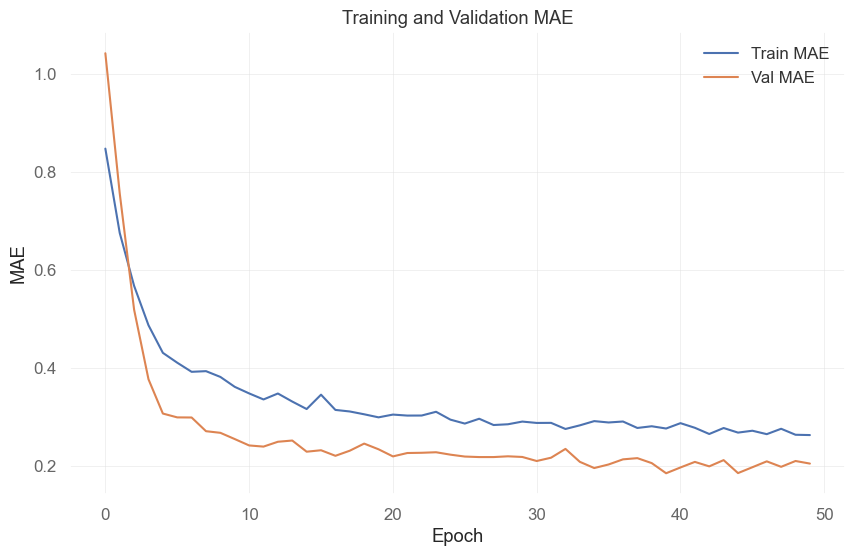

In [127]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

def build_and_train_dl_model(df_dl, feature_cols, target_col, 
                              train_ratio=0.6, val_ratio=0.2,
                              epochs=50, batch_size=32):
    """
    Build and train DNN model with proper 60/20/20 split.
    
    Parameters:
    -----------
    df_dl : DataFrame
        Complete dataframe with features and target
    feature_cols : list
        List of feature column names
    target_col : str
        Name of target column
    train_ratio : float
        Proportion for training (default 0.6)
    val_ratio : float
        Proportion for validation (default 0.2)
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
    
    Returns:
    --------
    model : keras.Model
        Trained DNN model
    history : keras.History
        Training history
    y_pred_scaled : ndarray
        Predictions on test set (scaled)
    y_test_scaled : ndarray
        Actual test values (scaled)
    r2_scaled : float
        R² score on scaled test data
    scalers : tuple
        (feature_scaler, target_scaler) for later use
    """
    
    tf.random.set_seed(42)
    
    # ============================================================
    # 1. Split data 60/20/20
    # ============================================================
    train_cutoff = int(len(df_dl) * train_ratio)
    val_cutoff = int(len(df_dl) * (train_ratio + val_ratio))
    
    df_train = df_dl.iloc[:train_cutoff]
    df_val = df_dl.iloc[train_cutoff:val_cutoff]
    df_test = df_dl.iloc[val_cutoff:]
    
    print(f"\nDataset Split:")
    print(f"  Training:   {len(df_train)} obs ({len(df_train)/len(df_dl)*100:.1f}%)")
    print(f"  Validation: {len(df_val)} obs ({len(df_val)/len(df_dl)*100:.1f}%)")
    print(f"  Test:       {len(df_test)} obs ({len(df_test)/len(df_dl)*100:.1f}%)")
    
    # ============================================================
    # 2. Extract features and targets
    # ============================================================
    x_train = df_train[feature_cols].values
    y_train = df_train[target_col].values.reshape(-1, 1)
    
    x_val = df_val[feature_cols].values
    y_val = df_val[target_col].values.reshape(-1, 1)
    
    x_test = df_test[feature_cols].values
    y_test = df_test[target_col].values.reshape(-1, 1)
    
    # ============================================================
    # 3. Scale data (fit on training only)
    # ============================================================
    feature_scaler = StandardScaler()
    x_train_scaled = feature_scaler.fit_transform(x_train)
    x_val_scaled = feature_scaler.transform(x_val)
    x_test_scaled = feature_scaler.transform(x_test)
    
    target_scaler = StandardScaler()
    y_train_scaled = target_scaler.fit_transform(y_train)
    y_val_scaled = target_scaler.transform(y_val)
    y_test_scaled = target_scaler.transform(y_test)
    
    # ============================================================
    # 4. Build model
    # ============================================================
    model = Sequential([
        Dense(32, activation="relu", input_shape=(x_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1)   # linear output for regression
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )
    
    # ============================================================
    # 5. Train model (validate on validation set)
    # ============================================================
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(
        x_train_scaled, y_train_scaled,
        validation_data=(x_val_scaled, y_val_scaled),  # Use validation set
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    # ============================================================
    # 6. Predictions on TEST set (never seen before)
    # ============================================================
    y_pred_scaled = model.predict(x_test_scaled, verbose=0)
    
    # Calculate metrics on scaled data
    r2_scaled = r2_score(y_test_scaled, y_pred_scaled)
    mae_scaled = mean_absolute_error(y_test_scaled, y_pred_scaled)
    mse_scaled = mean_squared_error(y_test_scaled, y_pred_scaled)
    
    print("\n" + "="*60)
    print("DNN MODEL - OUT-OF-SAMPLE PERFORMANCE (Test Set)")
    print("="*60)
    print(f"R² (scaled):  {r2_scaled:.4f}")
    print(f"MAE (scaled): {mae_scaled:.4f}")
    print(f"MSE (scaled): {mse_scaled:.4f}")
    print("="*60 + "\n")
    
    return model, history, y_pred_scaled, y_test_scaled, r2_scaled, (feature_scaler, target_scaler)


# ============================================================
# USAGE
# ============================================================

# Define features and target
feature_cols = [
    "garch_vol",
    "std_resid",
    "VIX_Returns_lag2",
    "M2_Money_Supply_return_lag2",
    "weighted_sentiment_vader_lag5",
    "realized_vol_3",
    "abs_return_3",
]

target_col = "target_vol"

# Call the function
dl_model, history, y_pred_scaled, y_test_scaled, r2_scaled, scalers = build_and_train_dl_model(
    df_dl=df_dl,
    feature_cols=feature_cols,
    target_col=target_col,
    train_ratio=0.6,
    val_ratio=0.2,
    epochs=50,
    batch_size=32
)

# Unpack scalers if needed"
feature_scaler, target_scaler = scalers

# Convert predictions to real volatility if needed
y_pred_log = target_scaler.inverse_transform(y_pred_scaled)
y_pred_real = np.expm1(y_pred_log)

y_test_log = target_scaler.inverse_transform(y_test_scaled)
y_test_real = np.expm1(y_test_log)

print(f"Real volatility MAE: {mean_absolute_error(y_test_real, y_pred_real):.6f}")

# Plot training history
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.legend()
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.show()

ExactExplainer explainer: 168it [00:31,  5.27it/s]                         


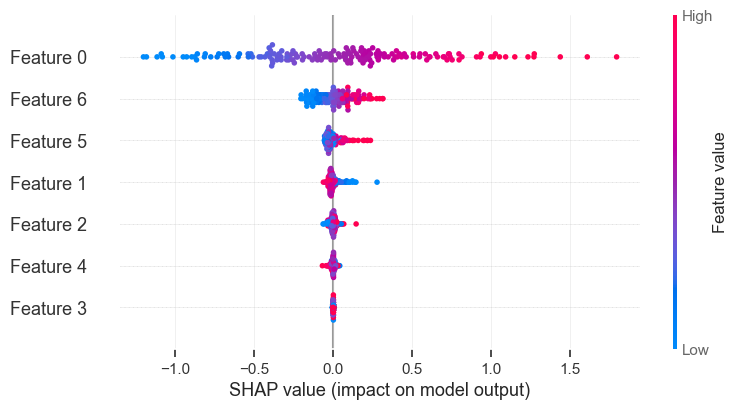

In [58]:
import shap
explainer = shap.Explainer(dl_model, x_test_scaled)
shap_values = explainer(x_test_scaled[:200])
shap.summary_plot(shap_values, pd.DataFrame(x_test_scaled, columns=feature_cols))


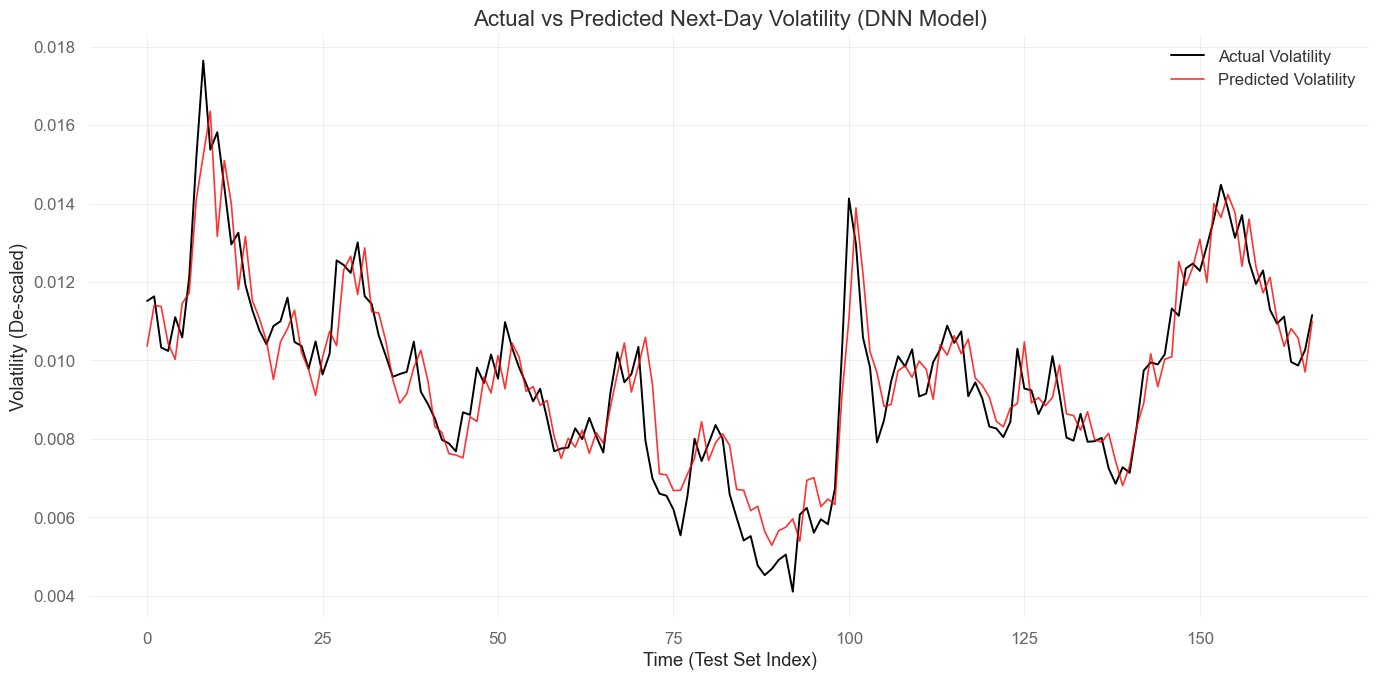

In [120]:
# Invert scaling
y_pred_log = target_scaler.inverse_transform(y_pred_scaled)
y_true_log = target_scaler.inverse_transform(y_test_scaled)

# convert log1p() → real volatility
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

# ============================================
# 4. Plot actual vs predicted volatility
# ============================================
plt.figure(figsize=(14,7))
plt.plot(y_true, label='Actual Volatility', color='black', linewidth=1.4)
plt.plot(y_pred, label='Predicted Volatility', color='red', linewidth=1.2, alpha=0.8)

plt.title("Actual vs Predicted Next-Day Volatility (DNN Model)", fontsize=16)
plt.xlabel("Time (Test Set Index)")
plt.ylabel("Volatility (De-scaled)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Skew: 0.40253652521386085
Kurtosis: 0.9370538561304191
Shapiro-Wilk p-value: 0.047627486288547516


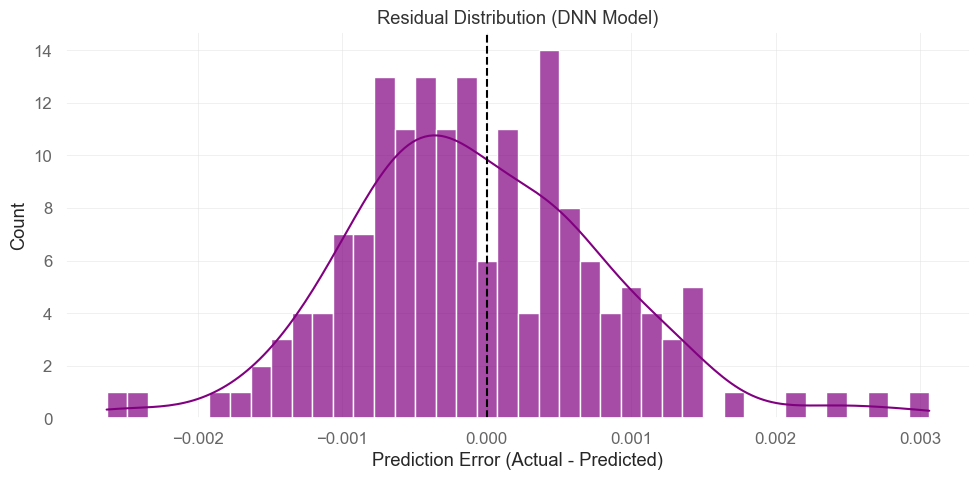

In [130]:
# Residual analysis (to confirm no bias)
residuals = y_true.flatten() - y_pred.flatten()
plt.figure(figsize=(10,5))
sns.histplot(residuals, bins=40, kde=True, color='purple', alpha=0.7)
plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution (DNN Model)")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.tight_layout()
plt.show


# Print final evaluation metrics
from scipy.stats import shapiro, skew, kurtosis

print("Skew:", skew(residuals))
print("Kurtosis:", kurtosis(residuals))
print("Shapiro-Wilk p-value:", shapiro(residuals)[1])


### Implementing LSTM Model


Dataset Split:
  Training:   499 obs (59.9%)
  Validation: 167 obs (20.0%)
  Test:       167 obs (20.0%)

LSTM Sequence Shapes:
  Training:   (494, 5, 7)
  Validation: (162, 5, 7)
  Testing:    (162, 5, 7)

Training Spike-Aware LSTM for 80 epochs...
Epoch 1/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.1155 - mae: 0.5708 - val_loss: 0.2255 - val_mae: 1.1314
Epoch 2/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0979 - mae: 0.4986 - val_loss: 0.2198 - val_mae: 1.1031
Epoch 3/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0927 - mae: 0.4333 - val_loss: 0.2192 - val_mae: 1.1006
Epoch 4/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0932 - mae: 0.4423 - val_loss: 0.2106 - val_mae: 1.0557
Epoch 5/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0824 - mae: 0.4167 - val_loss: 0.2022 - val_mae: 1.0109
Epoch 6/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0728 - mae: 0.3701 - val_loss: 0.1929 - val_mae: 0.9622
Epoch 7/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/s

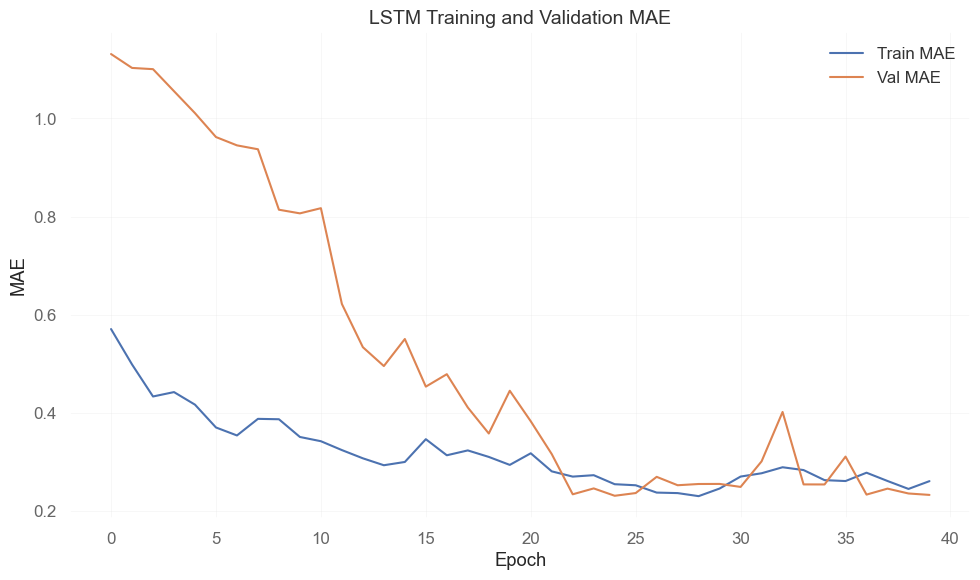

In [134]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# --- Weighted Huber Loss (more sensitive to spikes) ---
def weighted_huber_loss(delta=0.02):
    """Huber loss weighted to emphasize volatility spikes."""
    def loss(y_true, y_pred):
        err = y_true - y_pred
        abs_err = tf.abs(err)
        is_small = abs_err <= delta
        huber = tf.where(is_small,
                         0.5 * tf.square(err),
                         delta * abs_err - 0.5 * delta**2)
        # Heavier penalty on spikes
        weights = 1.0 + 8.0 * tf.abs(y_true) / (tf.reduce_mean(tf.abs(y_true)) + 1e-6)
        return tf.reduce_mean(weights * huber)
    return loss


def build_and_train_lstm_model(df_dl, feature_cols, target_col, 
                                train_ratio=0.6, val_ratio=0.2,
                                timesteps=5, epochs=80, batch_size=16):
    """
    Build and train LSTM model with proper 60/20/20 split.
    
    Parameters:
    -----------
    df_dl : DataFrame
        Complete dataframe with features and target
    feature_cols : list
        List of feature column names
    target_col : str
        Name of target column
    train_ratio : float
        Proportion for training (default 0.6)
    val_ratio : float
        Proportion for validation (default 0.2)
    timesteps : int
        Number of timesteps for LSTM sequences (default 5)
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
    
    Returns:
    --------
    model : keras.Model
        Trained LSTM model
    history : keras.History
        Training history
    y_pred_scaled : ndarray
        Predictions on test set (scaled)
    y_test_seq : ndarray
        Actual test values (scaled)
    r2_scaled : float
        R² score on scaled test data
    scalers : tuple
        (feature_scaler, target_scaler) for later use
    """
    
    np.random.seed(42)
    tf.random.set_seed(42)
    
    # ============================================================
    # 1. Split data 60/20/20
    # ============================================================
    train_cutoff = int(len(df_dl) * train_ratio)
    val_cutoff = int(len(df_dl) * (train_ratio + val_ratio))
    
    df_train = df_dl.iloc[:train_cutoff]
    df_val = df_dl.iloc[train_cutoff:val_cutoff]
    df_test = df_dl.iloc[val_cutoff:]
    
    print(f"\nDataset Split:")
    print(f"  Training:   {len(df_train)} obs ({len(df_train)/len(df_dl)*100:.1f}%)")
    print(f"  Validation: {len(df_val)} obs ({len(df_val)/len(df_dl)*100:.1f}%)")
    print(f"  Test:       {len(df_test)} obs ({len(df_test)/len(df_dl)*100:.1f}%)")
    
    # ============================================================
    # 2. Extract features and targets
    # ============================================================
    x_train = df_train[feature_cols].values
    y_train = df_train[target_col].values.reshape(-1, 1)
    
    x_val = df_val[feature_cols].values
    y_val = df_val[target_col].values.reshape(-1, 1)
    
    x_test = df_test[feature_cols].values
    y_test = df_test[target_col].values.reshape(-1, 1)
    
    # ============================================================
    # 3. Scale data (fit on training only)
    # ============================================================
    feature_scaler = StandardScaler()
    x_train_scaled = feature_scaler.fit_transform(x_train)
    x_val_scaled = feature_scaler.transform(x_val)
    x_test_scaled = feature_scaler.transform(x_test)
    
    target_scaler = StandardScaler()
    y_train_scaled = target_scaler.fit_transform(y_train)
    y_val_scaled = target_scaler.transform(y_val)
    y_test_scaled = target_scaler.transform(y_test)
    
    # ============================================================
    # 4. Create sequences for LSTM
    # ============================================================
    
    # TRAIN sequences
    X_train_seq, y_train_seq = [], []
    for i in range(timesteps, len(x_train_scaled)):
        X_train_seq.append(x_train_scaled[i - timesteps:i])
        y_train_seq.append(y_train_scaled[i])
    X_train_seq = np.array(X_train_seq)
    y_train_seq = np.array(y_train_seq)
    
    # VALIDATION sequences
    X_val_seq, y_val_seq = [], []
    for i in range(timesteps, len(x_val_scaled)):
        X_val_seq.append(x_val_scaled[i - timesteps:i])
        y_val_seq.append(y_val_scaled[i])
    X_val_seq = np.array(X_val_seq)
    y_val_seq = np.array(y_val_seq)
    
    # TEST sequences
    X_test_seq, y_test_seq = [], []
    for i in range(timesteps, len(x_test_scaled)):
        X_test_seq.append(x_test_scaled[i - timesteps:i])
        y_test_seq.append(y_test_scaled[i])
    X_test_seq = np.array(X_test_seq)
    y_test_seq = np.array(y_test_seq)
    
    print(f"\nLSTM Sequence Shapes:")
    print(f"  Training:   {X_train_seq.shape}")
    print(f"  Validation: {X_val_seq.shape}")
    print(f"  Testing:    {X_test_seq.shape}")
    
    # ============================================================
    # 5. Build LSTM model
    # ============================================================
    
    # Cosine decay learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=2e-3,
        first_decay_steps=30,
        m_mul=0.85,
        alpha=1e-5
    )
    
    model = Sequential([
        GaussianNoise(0.02, input_shape=(timesteps, x_train_scaled.shape[1])),
        
        LSTM(128, return_sequences=True, kernel_regularizer=l2(5e-5)),
        Dropout(0.1),
        
        LSTM(64, return_sequences=False, kernel_regularizer=l2(5e-5)),
        BatchNormalization(),
        
        Dense(32, activation='relu'),
        Dropout(0.05),
        
        Dense(1, activation='linear')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss=weighted_huber_loss(delta=0.02),
        metrics=['mae']
    )
    
    # ============================================================
    # 6. Train model (validate on validation set)
    # ============================================================
    
    early_stopping = EarlyStopping(
        monitor='val_mae', 
        patience=15, 
        restore_best_weights=True
    )
    
    print(f"\nTraining Spike-Aware LSTM for {epochs} epochs...")
    
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),  # Use validation set
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # ============================================================
    # 7. Evaluate on TEST set (never seen before)
    # ============================================================
    
    # Test metrics
    test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
    print(f"\n✅ Test Performance:")
    print(f"   Loss: {test_loss:.4f} | MAE: {test_mae:.4f}")
    
    # Train metrics (for comparison)
    train_loss, train_mae = model.evaluate(X_train_seq, y_train_seq, verbose=0)
    print(f"✅ Train Performance:")
    print(f"   Loss: {train_loss:.4f} | MAE: {train_mae:.4f}")
    
    # Predictions (scaled space)
    y_pred_scaled = model.predict(X_test_seq, verbose=0)
    
    # Calculate metrics
    r2_scaled = r2_score(y_test_seq, y_pred_scaled)
    mae_scaled = mean_absolute_error(y_test_seq, y_pred_scaled)
    mse_scaled = mean_squared_error(y_test_seq, y_pred_scaled)
    
    print("\n" + "="*60)
    print("LSTM MODEL - OUT-OF-SAMPLE PERFORMANCE (Test Set)")
    print("="*60)
    print(f"R² (scaled):  {r2_scaled:.4f}")
    print(f"MAE (scaled): {mae_scaled:.4f}")
    print(f"MSE (scaled): {mse_scaled:.4f}")
    print("="*60 + "\n")
    
    return model, history, y_pred_scaled, y_test_seq, r2_scaled, (feature_scaler, target_scaler)


# ============================================================
# USAGE
# ============================================================

# Define features and target
feature_cols = [
    "garch_vol",
    "std_resid",
    "VIX_Returns_lag2",
    "M2_Money_Supply_return_lag2",
    "weighted_sentiment_vader_lag5",
    "realized_vol_3",
    "abs_return_3",
]

target_col = "target_vol"

# Call the function
lstm_model, history_lstm, y_pred_lstm_scaled, y_test_lstm_seq, r2_lstm, scalers_lstm = build_and_train_lstm_model(
    df_dl=df_dl,
    feature_cols=feature_cols,
    target_col=target_col,
    train_ratio=0.6,
    val_ratio=0.2,
    timesteps=5,
    epochs=80,
    batch_size=16
)

# Unpack scalers
feature_scaler_lstm, target_scaler_lstm = scalers_lstm

# Convert predictions to real volatility
y_pred_lstm_log = target_scaler_lstm.inverse_transform(y_pred_lstm_scaled)
y_pred_lstm_real = np.expm1(y_pred_lstm_log)

y_test_lstm_log = target_scaler_lstm.inverse_transform(y_test_lstm_seq)
y_test_lstm_real = np.expm1(y_test_lstm_log)

print(f"Real volatility MAE: {mean_absolute_error(y_test_lstm_real, y_pred_lstm_real):.6f}")

# ============================================================
# Plot training history
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(history_lstm.history['mae'], label='Train MAE')
ax.plot(history_lstm.history['val_mae'], label='Val MAE')
ax.set_title('LSTM Training and Validation MAE', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


De-scaled MAE: 0.00107661 | De-scaled MSE: 0.00000216


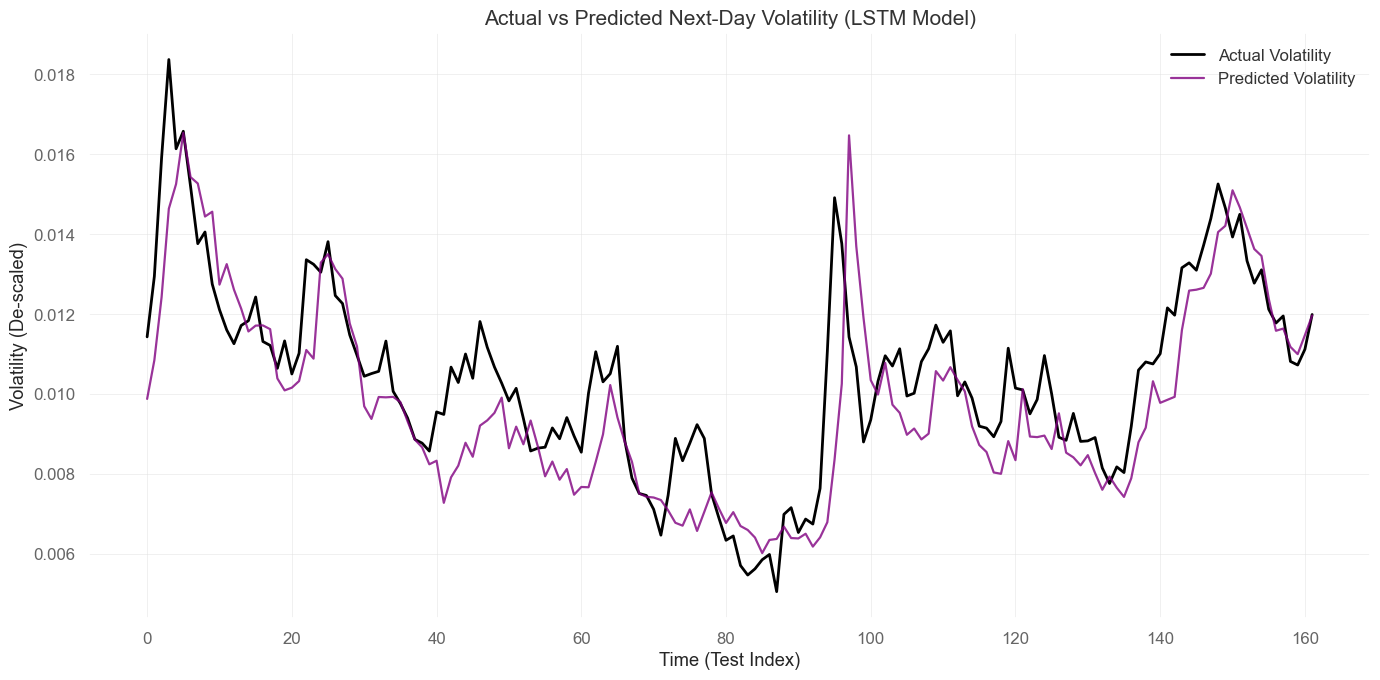

In [135]:
# ===============================
# 1. Predict (scaled log-vol)
# ===============================
y_pred_scaled = y_pred_lstm_scaled

# ===============================
# 2. Invert standardization
# ===============================
# reshape true y if needed
y_test_seq_reshaped = y_test_seq.reshape(-1, 1)

y_pred_log = target_scaler.inverse_transform(y_pred_scaled)
y_test_log_true = target_scaler.inverse_transform(y_test_seq_reshaped)

# ===============================
# 3. Convert from log-vol → real volatility
# ===============================
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log_true)

# ===============================
# 4. Metrics on real-scale volatility
# ===============================
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_real = mean_absolute_error(y_test_real, y_pred_real)
mse_real = mean_squared_error(y_test_real, y_pred_real)

print(f"De-scaled MAE: {mae_real:.8f} | De-scaled MSE: {mse_real:.8f}")

# ===============================
# 5. Plot Actual vs Predicted
# ===============================
plt.figure(figsize=(14,7))
plt.plot(y_test_real, label='Actual Volatility', linewidth=2, color='black')
plt.plot(y_pred_real, label='Predicted Volatility', linewidth=1.6, color='purple', alpha=0.8)

plt.title('Actual vs Predicted Next-Day Volatility (LSTM Model)', fontsize=15)
plt.xlabel('Time (Test Index)')
plt.ylabel('Volatility (De-scaled)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


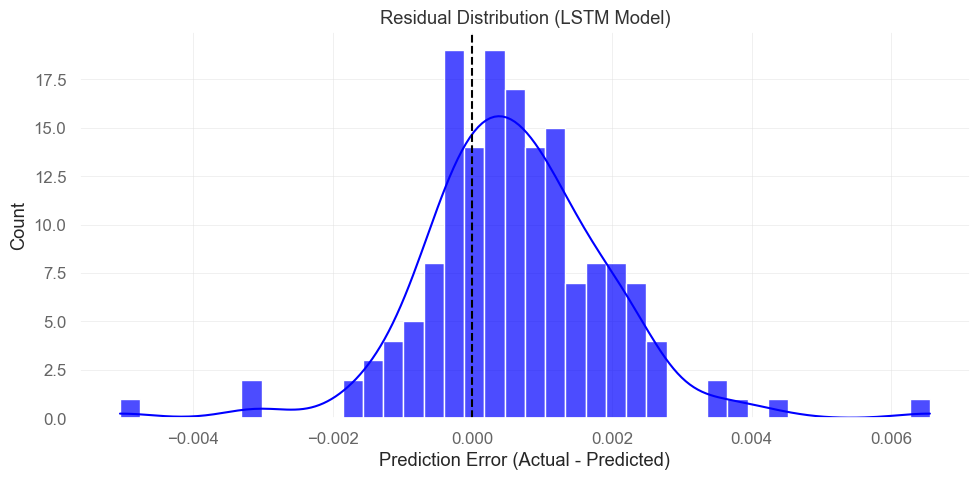

=== LSTM Residual Diagnostics ===
Skew: 0.13472645171424086
Kurtosis: 3.695530587371487
Shapiro-Wilk p-value: 2.1694437236874364e-05


In [136]:
# ==========================
# LSTM RESIDUAL ANALYSIS
# ==========================

# Compute LSTM residuals
lstm_residuals = y_test_real.flatten() - y_pred_real.flatten()

plt.figure(figsize=(10,5))
sns.histplot(lstm_residuals, bins=40, kde=True, color='blue', alpha=0.7)
plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution (LSTM Model)")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Normality + distribution diagnostics
from scipy.stats import shapiro, skew, kurtosis

print("=== LSTM Residual Diagnostics ===")
print("Skew:", skew(lstm_residuals))
print("Kurtosis:", kurtosis(lstm_residuals))
print("Shapiro-Wilk p-value:", shapiro(lstm_residuals)[1])


STEP 1: TRAINING DNN MODEL

Dataset Split:
  Training:   499 obs (59.9%)
  Validation: 167 obs (20.0%)
  Test:       167 obs (20.0%)
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.7241 - mae: 0.6812 - val_loss: 0.6570 - val_mae: 0.7400
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4901 - mae: 0.5541 - val_loss: 0.3332 - val_mae: 0.5009
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3816 - mae: 0.4690 - val_loss: 0.1861 - val_mae: 0.3488
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2793 - mae: 0.4229 - val_loss: 0.1164 - val_mae: 0.2636
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2761 - mae: 0.4023 - val_loss: 0.0995 - val_mae: 0.2424
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2315 - mae: 0.3716 - val_loss: 0.0839 - val_mae: 0.2224
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2135 - mae: 0.3614 - val_loss: 0.0694 - val_mae: 0.2027
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/st

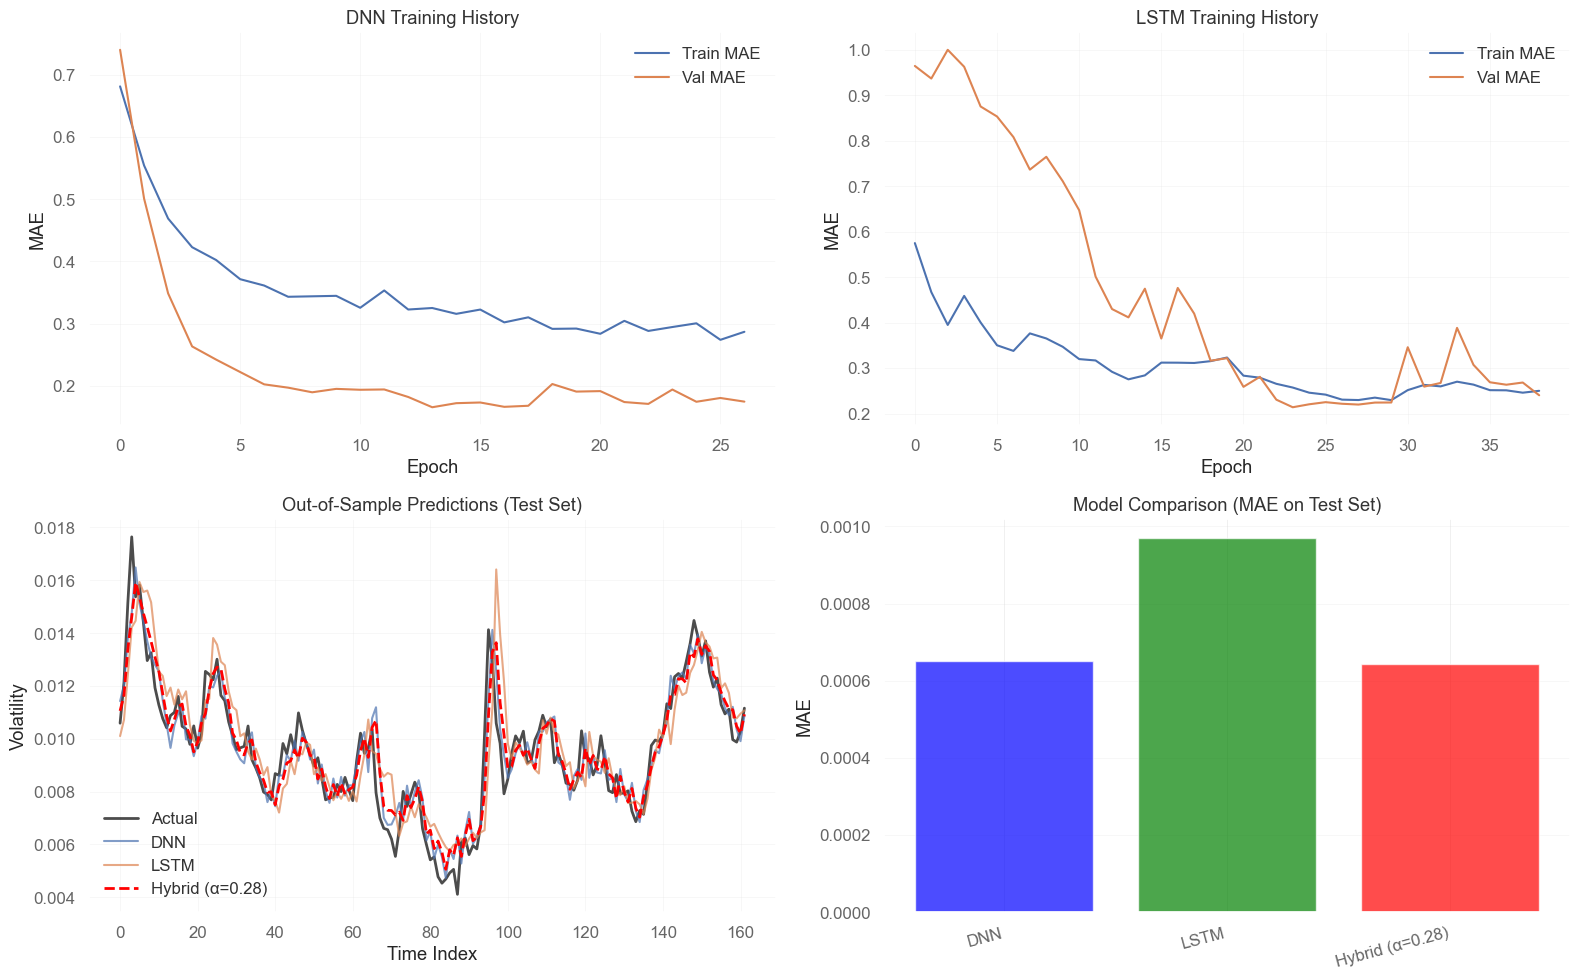

In [63]:
def create_hybrid_ensemble(dl_model, lstm_model, df_dl, feature_cols, target_col,
                          feature_scaler_dl, target_scaler_dl,
                          feature_scaler_lstm, target_scaler_lstm,
                          train_ratio=0.6, val_ratio=0.2, seq_length=5):
    """
    Create hybrid ensemble by optimizing α on validation set.
    Uses pre-trained DNN and LSTM models.
    
    Parameters:
    -----------
    dl_model : keras.Model
        Trained DNN model
    lstm_model : keras.Model
        Trained LSTM model
    df_dl : DataFrame
        Complete dataframe with features and target
    feature_cols : list
        List of feature column names
    target_col : str
        Name of target column
    feature_scaler_dl : StandardScaler
        Scaler used for DNN features
    target_scaler_dl : StandardScaler
        Scaler used for DNN target
    feature_scaler_lstm : StandardScaler
        Scaler used for LSTM features
    target_scaler_lstm : StandardScaler
        Scaler used for LSTM target
    train_ratio : float
        Training proportion (default 0.6)
    val_ratio : float
        Validation proportion (default 0.2)
    seq_length : int
        LSTM sequence length (default 5)
    
    Returns:
    --------
    results : dict
        Dictionary containing:
        - best_alpha: optimal ensemble weight
        - predictions: dict with dnn, lstm, hybrid predictions
        - actuals: y_test_real
        - metrics: DataFrame with performance metrics
    """
    
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np
    import pandas as pd
    
    # ============================================================
    # 1. Split data 60/20/20
    # ============================================================
    train_cutoff = int(len(df_dl) * train_ratio)
    val_cutoff = int(len(df_dl) * (train_ratio + val_ratio))
    
    df_train = df_dl.iloc[:train_cutoff]
    df_val = df_dl.iloc[train_cutoff:val_cutoff]
    df_test = df_dl.iloc[val_cutoff:]
    
    print(f"\n{'='*60}")
    print("HYBRID ENSEMBLE - DATA SPLIT")
    print(f"{'='*60}")
    print(f"Training:   {len(df_train)} obs ({len(df_train)/len(df_dl)*100:.1f}%)")
    print(f"Validation: {len(df_val)} obs ({len(df_val)/len(df_dl)*100:.1f}%)")
    print(f"Test:       {len(df_test)} obs ({len(df_test)/len(df_dl)*100:.1f}%)")
    print(f"{'='*60}\n")
    
    # ============================================================
    # 2. Extract and scale VALIDATION set
    # ============================================================
    x_val = df_val[feature_cols].values
    y_val = df_val[target_col].values.reshape(-1, 1)
    
    # Scale validation features (using DNN scaler)
    x_val_scaled = feature_scaler_dl.transform(x_val)
    y_val_scaled = target_scaler_dl.transform(y_val)
    
    # ============================================================
    # 3. Get DNN predictions on VALIDATION set
    # ============================================================
    y_pred_dl_val_scaled = dl_model.predict(x_val_scaled, verbose=0)
    
    # ============================================================
    # 4. Get LSTM predictions on VALIDATION set
    # ============================================================
    # Create sequences for LSTM
    def create_sequences(X, y, seq_len):
        X_seq, y_seq = [], []
        for i in range(seq_len, len(X)):
            X_seq.append(X[i - seq_len:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)
    
    X_val_seq, y_val_seq = create_sequences(x_val_scaled, y_val_scaled, seq_length)
    y_pred_lstm_val_scaled = lstm_model.predict(X_val_seq, verbose=0)
    
    # ============================================================
    # 5. Align lengths and convert to real volatility (VALIDATION)
    # ============================================================
    min_len_val = min(len(y_pred_dl_val_scaled), len(y_pred_lstm_val_scaled), len(y_val_seq))
    y_pred_dl_val_scaled = y_pred_dl_val_scaled[-min_len_val:]
    y_pred_lstm_val_scaled = y_pred_lstm_val_scaled[-min_len_val:]
    y_val_seq_aligned = y_val_seq[-min_len_val:]
    
    # Convert to real volatility
    y_pred_dl_val_real = np.expm1(target_scaler_dl.inverse_transform(y_pred_dl_val_scaled))
    y_pred_lstm_val_real = np.expm1(target_scaler_lstm.inverse_transform(y_pred_lstm_val_scaled))
    y_val_real = np.expm1(target_scaler_dl.inverse_transform(y_val_seq_aligned.reshape(-1, 1)))
    
    # ============================================================
    # 6. Optimize α on VALIDATION set
    # ============================================================
    alphas = np.linspace(0, 1, 51)
    best_alpha, best_mae = 0, float('inf')
    
    for a in alphas:
        y_mix_val = a * y_pred_lstm_val_real + (1 - a) * y_pred_dl_val_real
        mae = mean_absolute_error(y_val_real, y_mix_val)
        if mae < best_mae:
            best_mae = mae
            best_alpha = a
    
    print(f"{'='*60}")
    print("ENSEMBLE OPTIMIZATION (Validation Set)")
    print(f"{'='*60}")
    print(f"Optimal α: {best_alpha:.4f}")
    print(f"  → {best_alpha*100:.1f}% LSTM + {(1-best_alpha)*100:.1f}% DNN")
    print(f"Validation MAE: {best_mae:.6f}")
    print(f"{'='*60}\n")
    
    # ============================================================
    # 7. Extract and scale TEST set
    # ============================================================
    x_test = df_test[feature_cols].values
    y_test = df_test[target_col].values.reshape(-1, 1)
    
    x_test_scaled = feature_scaler_dl.transform(x_test)
    y_test_scaled = target_scaler_dl.transform(y_test)
    
    # ============================================================
    # 8. Get DNN predictions on TEST set
    # ============================================================
    y_pred_dl_test_scaled = dl_model.predict(x_test_scaled, verbose=0)
    
    # ============================================================
    # 9. Get LSTM predictions on TEST set
    # ============================================================
    X_test_seq, y_test_seq = create_sequences(x_test_scaled, y_test_scaled, seq_length)
    y_pred_lstm_test_scaled = lstm_model.predict(X_test_seq, verbose=0)
    
    # ============================================================
    # 10. Align lengths and convert to real volatility (TEST)
    # ============================================================
    min_len_test = min(len(y_pred_dl_test_scaled), len(y_pred_lstm_test_scaled), len(y_test_seq))
    y_pred_dl_test_scaled = y_pred_dl_test_scaled[-min_len_test:]
    y_pred_lstm_test_scaled = y_pred_lstm_test_scaled[-min_len_test:]
    y_test_seq_aligned = y_test_seq[-min_len_test:]
    
    # Convert to real volatility
    y_pred_dl_test_real = np.expm1(target_scaler_dl.inverse_transform(y_pred_dl_test_scaled))
    y_pred_lstm_test_real = np.expm1(target_scaler_lstm.inverse_transform(y_pred_lstm_test_scaled))
    y_test_real = np.expm1(target_scaler_dl.inverse_transform(y_test_seq_aligned.reshape(-1, 1)))
    
    # ============================================================
    # 11. Apply α from validation set to TEST predictions
    # ============================================================
    y_pred_hybrid_test = best_alpha * y_pred_lstm_test_real + (1 - best_alpha) * y_pred_dl_test_real
    
    # ============================================================
    # 12. Calculate metrics on TEST set
    # ============================================================
    def compute_metrics(y_true, y_pred):
        return {
            "MAE": mean_absolute_error(y_true, y_pred),
            "MSE": mean_squared_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R²": r2_score(y_true, y_pred)
        }
    
    metrics = {
        "DNN": compute_metrics(y_test_real, y_pred_dl_test_real),
        "LSTM": compute_metrics(y_test_real, y_pred_lstm_test_real),
        f"Hybrid (α={best_alpha:.2f})": compute_metrics(y_test_real, y_pred_hybrid_test)
    }
    
    df_metrics = pd.DataFrame(metrics).T
    
    print(f"\n{'='*60}")
    print("OUT-OF-SAMPLE PERFORMANCE (Test Set)")
    print(f"{'='*60}")
    print(df_metrics.round(6))
    print(f"\n✓ Best model (lowest MAE): {df_metrics['MAE'].idxmin()}")
    print(f"{'='*60}\n")
    
    # ============================================================
    # 13. Return results
    # ============================================================
    results = {
        'best_alpha': best_alpha,
        'predictions': {
            'dnn': y_pred_dl_test_real,
            'lstm': y_pred_lstm_test_real,
            'hybrid': y_pred_hybrid_test
        },
        'actuals': y_test_real,
        'metrics': df_metrics
    }
    
    return results


# ============================================================
# USAGE - COMPLETE WORKFLOW
# ============================================================

# Step 1: Train DNN
print("="*60)
print("STEP 1: TRAINING DNN MODEL")
print("="*60)

dl_model, history_dl, y_pred_dl_scaled, y_test_dl_scaled, r2_dl, scalers_dl = build_and_train_dl_model(
    df_dl=df_dl,
    feature_cols=feature_cols,
    target_col=target_col,
    train_ratio=0.6,
    val_ratio=0.2,
    epochs=50,
    batch_size=32
)

feature_scaler_dl, target_scaler_dl = scalers_dl

# Step 2: Train LSTM
print("\n" + "="*60)
print("STEP 2: TRAINING LSTM MODEL")
print("="*60)

lstm_model, history_lstm, y_pred_lstm_scaled, y_test_lstm_seq, r2_lstm, scalers_lstm = build_and_train_lstm_model(
    df_dl=df_dl,
    feature_cols=feature_cols,
    target_col=target_col,
    train_ratio=0.6,
    val_ratio=0.2,
    timesteps=5,
    epochs=80,
    batch_size=16
)

feature_scaler_lstm, target_scaler_lstm = scalers_lstm

# Step 3: Create Hybrid Ensemble
print("\n" + "="*60)
print("STEP 3: CREATING HYBRID ENSEMBLE")
print("="*60)

hybrid_results = create_hybrid_ensemble(
    dl_model=dl_model,
    lstm_model=lstm_model,
    df_dl=df_dl,
    feature_cols=feature_cols,
    target_col=target_col,
    feature_scaler_dl=feature_scaler_dl,
    target_scaler_dl=target_scaler_dl,
    feature_scaler_lstm=feature_scaler_lstm,
    target_scaler_lstm=target_scaler_lstm,
    train_ratio=0.6,
    val_ratio=0.2,
    seq_length=5
)

# Access results
best_alpha = hybrid_results['best_alpha']
df_metrics = hybrid_results['metrics']
y_test_real = hybrid_results['actuals']
y_pred_hybrid = hybrid_results['predictions']['hybrid']

print(f"\n✓ Complete workflow finished!")
print(f"✓ Optimal α: {best_alpha:.4f} (optimized on validation set)")
print(f"✓ Best model: {df_metrics['MAE'].idxmin()}")

# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Training history - DNN
axes[0, 0].plot(history_dl.history['mae'], label='Train MAE')
axes[0, 0].plot(history_dl.history['val_mae'], label='Val MAE')
axes[0, 0].set_title('DNN Training History')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Training history - LSTM
axes[0, 1].plot(history_lstm.history['mae'], label='Train MAE')
axes[0, 1].plot(history_lstm.history['val_mae'], label='Val MAE')
axes[0, 1].set_title('LSTM Training History')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Predictions comparison
axes[1, 0].plot(y_test_real, label='Actual', color='black', linewidth=2, alpha=0.7)
axes[1, 0].plot(hybrid_results['predictions']['dnn'], label='DNN', alpha=0.7)
axes[1, 0].plot(hybrid_results['predictions']['lstm'], label='LSTM', alpha=0.7)
axes[1, 0].plot(hybrid_results['predictions']['hybrid'], 
                label=f'Hybrid (α={best_alpha:.2f})', 
                color='red', linewidth=2, linestyle='--')
axes[1, 0].set_title('Out-of-Sample Predictions (Test Set)')
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Volatility')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Performance comparison bar chart
axes[1, 1].bar(df_metrics.index, df_metrics['MAE'], 
               alpha=0.7, color=['blue', 'green', 'red'])
axes[1, 1].set_title('Model Comparison (MAE on Test Set)')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_xticklabels(df_metrics.index, rotation=15, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Predictions comparison
fig, ax = plt.subplots(figsize=(16, 10))
ax.plot(y_test_real, label='Actual', color='black', linewidth=2, alpha=0.7)
ax.plot(hybrid_results['predictions']['dnn'], label='DNN', alpha=0.7)
ax.plot(hybrid_results['predictions']['lstm'], label='LSTM', alpha=0.7)
ax.plot(hybrid_results['predictions']['hybrid'], 
                label=f'Hybrid (α={best_alpha:.2f})', 
                color='red', linewidth=2, linestyle='--')
ax.set_title('Out-of-Sample Predictions (Test Set)')
ax.set_xlabel('Time Index')
ax.set_ylabel('Volatility')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plot' is not defined

In [65]:
# Calculate forecast error standard deviation
errors_dnn = y_test_real - hybrid_results['predictions']['dnn']
errors_hybrid = y_test_real - hybrid_results['predictions']['hybrid']

std_dnn = np.std(errors_dnn)
std_hybrid = np.std(errors_hybrid)

print(f"DNN forecast std: {std_dnn:.6f}")
print(f"Hybrid forecast std: {std_hybrid:.6f}")

DNN forecast std: 0.000863
Hybrid forecast std: 0.000881


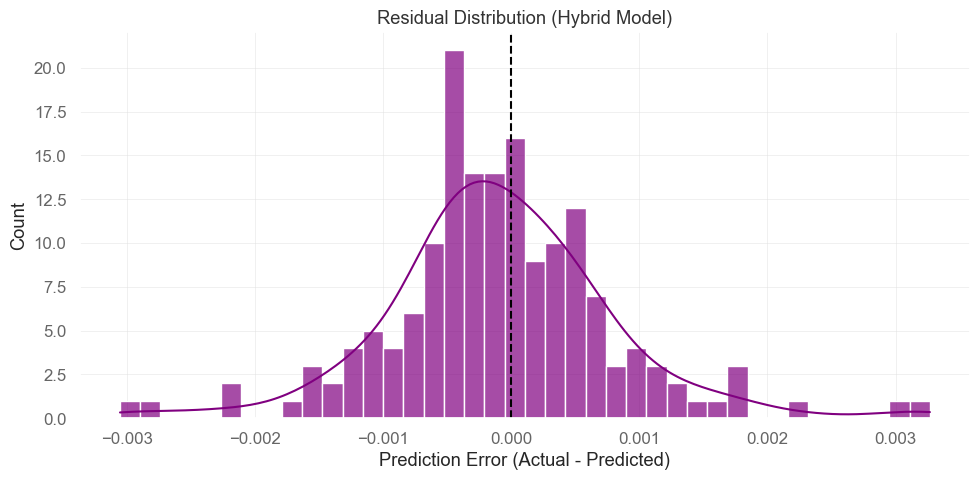

=== Hybrid Residual Diagnostics ===
Skew: 0.28708588989404493
Kurtosis: 2.43253843228334
Shapiro-Wilk p-value: 0.00012998063175473362


In [117]:
# ==========================
# HYBRID RESIDUAL ANALYSIS
# ==========================

# Compute Hybrid residuals
hybrid_residuals = y_test_real.flatten() - y_pred_hybrid.flatten()

plt.figure(figsize=(10,5))
sns.histplot(hybrid_residuals, bins=40, kde=True, color='purple', alpha=0.7)
plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution (Hybrid Model)")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Normality + distribution diagnostics
from scipy.stats import shapiro, skew, kurtosis

print("=== Hybrid Residual Diagnostics ===")
print("Skew:", skew(hybrid_residuals))
print("Kurtosis:", kurtosis(hybrid_residuals))
print("Shapiro-Wilk p-value:", shapiro(hybrid_residuals)[1])


In [116]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================================
# CREATE COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================

def create_full_comparison_table(garch_vol, garchx_vol, 
                                 y_test_real, 
                                 y_pred_dnn, y_pred_lstm, y_pred_hybrid,
                                 best_alpha):
    """
    Create comprehensive comparison table including GARCH and deep learning models.
    
    Parameters:
    -----------
    garch_vol : array-like
        Conditional volatility from baseline GARCH(1,1)
    garchx_vol : array-like
        Conditional volatility from GARCH-X (skew-t)
    y_test_real : array-like
        Actual test set volatility (real scale)
    y_pred_dnn : array-like
        DNN predictions (real scale)
    y_pred_lstm : array-like
        LSTM predictions (real scale)
    y_pred_hybrid : array-like
        Hybrid predictions (real scale)
    best_alpha : float
        Optimal ensemble weight
    
    Returns:
    --------
    df_full : DataFrame
        Complete comparison table
    """
    
    # ============================================================
    # 1. Align GARCH models to test set indices
    # ============================================================
    
    # Get test set indices (last 20% of data)
    test_start_idx = int(len(garch_vol) * 0.8)
    
    # Extract GARCH predictions for test period
    garch_test = garch_vol.iloc[test_start_idx:].values
    garchx_test = garchx_vol.iloc[test_start_idx:].values
    
    # Align lengths (in case of sequence-based models having fewer predictions)
    min_len = min(len(garch_test), len(garchx_test), len(y_test_real))
    
    garch_test = garch_test[-min_len:]
    garchx_test = garchx_test[-min_len:]
    y_test_aligned = y_test_real[-min_len:].flatten()
    y_pred_dnn_aligned = y_pred_dnn[-min_len:].flatten()
    y_pred_lstm_aligned = y_pred_lstm[-min_len:].flatten()
    y_pred_hybrid_aligned = y_pred_hybrid[-min_len:].flatten()
    
    # ============================================================
    # 2. Calculate metrics for all models
    # ============================================================
    
    def compute_metrics(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        
        # Forecast error std
        errors = y_true - y_pred
        std_error = np.std(errors)
        
        return {
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R²": r2,
            "Error Std": std_error
        }
    
    # Calculate for all models
    metrics = {
        "GARCH(1,1)": compute_metrics(y_test_aligned, garch_test),
        "GARCH-X (skew-t)": compute_metrics(y_test_aligned, garchx_test),
        "DNN": compute_metrics(y_test_aligned, y_pred_dnn_aligned),
        "LSTM": compute_metrics(y_test_aligned, y_pred_lstm_aligned),
        f"Hybrid (α={best_alpha:.2f})": compute_metrics(y_test_aligned, y_pred_hybrid_aligned)
    }
    
    # Create DataFrame
    df_full = pd.DataFrame(metrics).T
    
    # ============================================================
    # 3. Add % improvement vs baseline GARCH
    # ============================================================
    
    baseline_mae = df_full.loc["GARCH(1,1)", "MAE"]
    df_full["% Improv. vs GARCH"] = ((baseline_mae - df_full["MAE"]) / baseline_mae * 100)
    
    # ============================================================
    # 4. Add ranking
    # ============================================================
    
    df_full["Rank"] = df_full["MAE"].rank().astype(int)
    
    # Reorder columns
    df_full = df_full[["MAE", "MSE", "RMSE", "R²", "Error Std", "% Improv. vs GARCH", "Rank"]]
    
    return df_full, (garch_test, garchx_test, y_test_aligned, 
                     y_pred_dnn_aligned, y_pred_lstm_aligned, y_pred_hybrid_aligned)


# ============================================================
# USAGE
# ============================================================

# Create the full comparison table
df_full_comparison, aligned_preds = create_full_comparison_table(
    garch_vol=vol_base,          # Baseline GARCH(1,1) volatility
    garchx_vol=cond_vol_final,   # GARCH-X (skew-t) volatility
    y_test_real=hybrid_results['actuals'],
    y_pred_dnn=hybrid_results['predictions']['dnn'],
    y_pred_lstm=hybrid_results['predictions']['lstm'],
    y_pred_hybrid=hybrid_results['predictions']['hybrid'],
    best_alpha=hybrid_results['best_alpha']
)

# Unpack aligned predictions for plotting
garch_test, garchx_test, y_test_aligned, y_pred_dnn_aligned, y_pred_lstm_aligned, y_pred_hybrid_aligned = aligned_preds

# ============================================================
# DISPLAY TABLE
# ============================================================

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON - OUT-OF-SAMPLE PERFORMANCE (Test Set)")
print("="*80)
print(df_full_comparison.round(6))
print("\n✓ Best model (lowest MAE):", df_full_comparison['MAE'].idxmin())
print("="*80 + "\n")

# ============================================================
# SAVE AS STYLED IMAGE
# ============================================================

def save_table_as_image(df, filename='model_comparison_table.png', dpi=300):
    """
    Save DataFrame as a high-quality image suitable for papers.
    """
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.axis('tight')
    ax.axis('off')
    
    # Format the dataframe for display
    df_display = df.copy()
    
    # Round numeric columns
    for col in df_display.columns:
        if col not in ['Rank']:
            df_display[col] = df_display[col].apply(lambda x: f'{x:.6f}' if abs(x) < 0.01 else f'{x:.4f}')
    
    # Create table
    table = ax.table(
        cellText=df_display.values,
        rowLabels=df_display.index,
        colLabels=df_display.columns,
        cellLoc='center',
        loc='center',
        colWidths=[0.12] * len(df_display.columns)
    )
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Header styling
    for i in range(len(df_display.columns)):
        cell = table[(0, i)]
        cell.set_facecolor('#4472C4')
        cell.set_text_props(weight='bold', color='white')
    
    # Row label styling
    for i in range(1, len(df_display) + 1):
        cell = table[(i, -1)]
        cell.set_facecolor('#D9E1F2')
        cell.set_text_props(weight='bold')
    
    # Highlight best model (lowest MAE)
    best_idx = df['MAE'].idxmin()
    best_row = list(df.index).index(best_idx) + 1
    for i in range(len(df_display.columns)):
        cell = table[(best_row, i)]
        cell.set_facecolor('#C6E0B4')
        cell.set_text_props(weight='bold')
    
    plt.title('Out-of-Sample Forecasting Performance Comparison', 
              fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"\n✓ Table saved as '{filename}'")
    plt.show()

# Save the table as image
save_table_as_image(df_full_comparison, 'model_comparison_table.png', dpi=300)

# ============================================================
# ENHANCED VISUALIZATION - ALL MODELS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: All model predictions
axes[0, 0].plot(y_test_aligned, label='Actual', color='black', linewidth=2, alpha=0.8)
axes[0, 0].plot(garch_test, label='GARCH(1,1)', alpha=0.6, linestyle=':')
axes[0, 0].plot(garchx_test, label='GARCH-X', alpha=0.6, linestyle='--')
axes[0, 0].plot(y_pred_dnn_aligned, label='DNN', alpha=0.7)
axes[0, 0].plot(y_pred_lstm_aligned, label='LSTM', alpha=0.7)
axes[0, 0].plot(y_pred_hybrid_aligned, label=f'Hybrid (α={hybrid_results["best_alpha"]:.2f})', 
                color='red', linewidth=2, linestyle='--')
axes[0, 0].set_title('Out-of-Sample Predictions - All Models', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Volatility')
axes[0, 0].legend(loc='best', fontsize=9)
axes[0, 0].grid(alpha=0.3)

# Plot 2: MAE comparison
mae_values = df_full_comparison['MAE'].values
model_names = df_full_comparison.index
colors = ['lightblue', 'lightgreen', 'blue', 'green', 'red']
bars = axes[0, 1].bar(range(len(model_names)), mae_values, color=colors, alpha=0.7)
axes[0, 1].set_xticks(range(len(model_names)))
axes[0, 1].set_xticklabels(model_names, rotation=15, ha='right')
axes[0, 1].set_title('MAE Comparison (Test Set)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, mae_values)):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                    f'{val:.6f}', ha='center', va='bottom', fontsize=8)

# Plot 3: % Improvement vs GARCH
improv = df_full_comparison['% Improv. vs GARCH'].values
colors_improv = ['gray' if x < 0 else 'green' for x in improv]
bars = axes[1, 0].bar(range(len(model_names)), improv, color=colors_improv, alpha=0.7)
axes[1, 0].set_xticks(range(len(model_names)))
axes[1, 0].set_xticklabels(model_names, rotation=15, ha='right')
axes[1, 0].set_title('% Improvement vs Baseline GARCH(1,1)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('% Improvement')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, improv)):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                    f'{val:.1f}%', ha='center', va='bottom' if val > 0 else 'top', fontsize=8)

# Plot 4: Forecast error standard deviation
error_stds = df_full_comparison['Error Std'].values
bars = axes[1, 1].bar(range(len(model_names)), error_stds, color=colors, alpha=0.7)
axes[1, 1].set_xticks(range(len(model_names)))
axes[1, 1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1, 1].set_title('Forecast Error Volatility', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Error Std Dev')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, error_stds)):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                    f'{val:.6f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('comprehensive_model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Comprehensive visualization saved as 'comprehensive_model_comparison.png'")

ValueError: Found input variables with inconsistent numbers of samples: [162, 264]

In [112]:
cond_vol_final.shape

(835,)

In [113]:
vol_base.shape

(1317,)

In [114]:
df_full = create_full_comparison_table_simple(
    vol_base,
    cond_vol_final,
    hybrid_results["actuals"],
    hybrid_results["predictions"]["dnn"],
    hybrid_results["predictions"]["lstm"],
    hybrid_results["predictions"]["hybrid"],
    hybrid_results["best_alpha"]
)

print(df_full)


                       MAE       MSE      RMSE      R²  Error Std  \
GARCH(1,1)        0.001202  0.000002  0.001561  0.5790   0.001513   
GARCH-X (skew-t)  0.000000  0.000000  0.000000  1.0000   0.000000   
DNN               0.000652  0.000001  0.000864  0.8709   0.000863   
LSTM              0.000971  0.000002  0.001319  0.6994   0.001308   
Hybrid (α=0.28)   0.000644  0.000001  0.000885  0.8645   0.000881   

                  % Improv vs GARCH  Rank  
GARCH(1,1)                     0.00     5  
GARCH-X (skew-t)             100.00     1  
DNN                           45.74     3  
LSTM                          19.23     4  
Hybrid (α=0.28)               46.43     2  


### Save models and scalers

In [ ]:
### Save Models and Scalers for Future Inference ###
dl_model.save('dl_garch_model.keras')
lstm_model.save('lstm_volatility_model.keras')

import joblib
joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

print("✅ Models and scalers saved successfully.")


✅ Models and scalers saved successfully.


## Testing for Robustness

In [ ]:
# Combine aligned returns, exogenous features, and GARCH vol
final_dataset = pd.concat(
    [aligned_returns, exog_features, cond_vol_final],
    axis=1
)

final_dataset.columns = (
    ["SPX_Returns"] +
    list(exog_features.columns) +
    ["garch_std", "garch_skt"]
)

# Realized 3-day volatility (rolling variance of SPX returns)
final_dataset["realized_vol_3"] = final_dataset["SPX_Returns"].rolling(3).var()

# 3-day absolute return sum (shock / momentum indicator)
final_dataset["abs_return_3"] = final_dataset["SPX_Returns"].abs().rolling(3).sum()

# Drop initial rows with NaNs from rolling/lags
final_dataset = final_dataset.dropna()

final_dataset.to_csv("final_processed_volatility_dataset.csv")
print("✅ Saved full processed dataset to final_processed_volatility_dataset.csv")


✅ Saved full processed dataset to final_processed_volatility_dataset.csv


✅ All feature columns present.
Train shape: (538, 7) | Test shape: (241, 7)
X_test_seq: (231, 10, 7) | y_test_scaled_lstm: (231, 1)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

=== MODEL PERFORMANCE ON NEW TIMEFRAME ===
                      MAE       MSE        R²
DNN              0.075614  0.008262  0.700793
LSTM             0.116632  0.027396  0.007809
Hybrid (α=0.08)  0.069896  0.007134  0.741632

✅ Best model (lowest MAE): Hybrid (α=0.08)


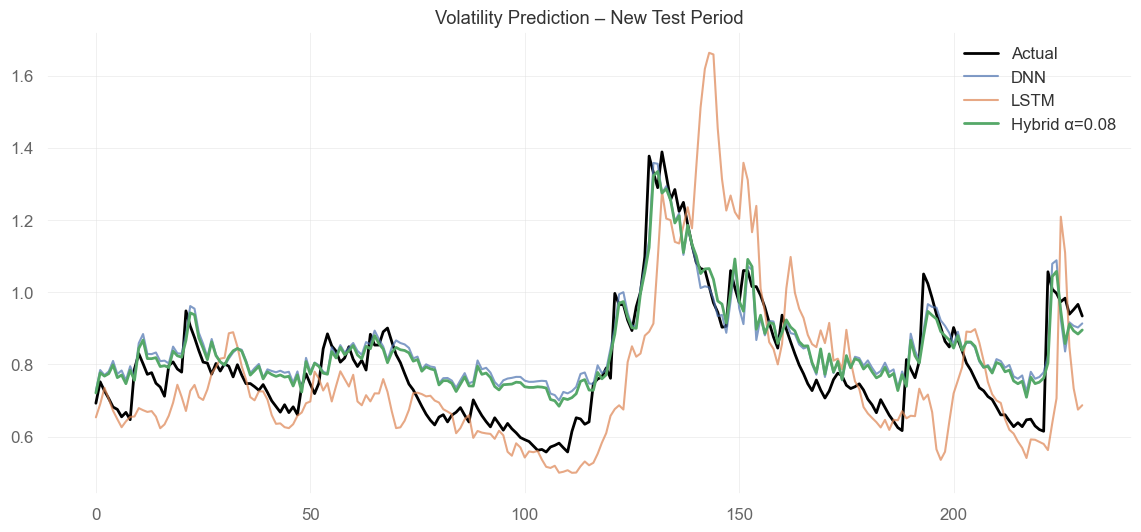